---
title: "STAT 301 Project Individual Planning Stage"
author: Kaiyan (Nathan) Zhang <br> 97133094
date: 2025-07-24
---

In [1]:
# Package Loading
library(tidyverse)
library(ggplot2)
library(ggmap)
library(patchwork)
library(GGally)
library(janitor)
library(broom)
library(car)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
ℹ Google's Terms of Service: <https://mapsplatform.google.com>
  Stadia Maps' Terms of Service: <https://stadiamaps.com/terms-of-service>
  OpenStreetMap's Tile Usage Policy: <https://operations.osmfoundation.org/policies/tiles>
ℹ Please cite ggmap if you use it! Use `citation("ggmap")` for details.

Attaching package: 'janitor'


The following objects are masked from 'package:stats':

    chisq.test, fisher.test


Loading required package: carData


Attaching package: 'c

### Task (1) Dataset Description

#### Data Preprocessing
Before begining: I downloaded the zipped datasets in from Kaggle [https://www.kaggle.com/datasets/thedevastator/airbnb-prices-in-european-cities/data](https://www.kaggle.com/datasets/thedevastator/airbnb-prices-in-european-cities/data) directly, uploaded the unzipped data via added to GitHub repo and process all the `.csv` files to one single dataset for further analysis.

In [2]:
# Merge the datasets from the Github repository
# Define the GitHub directory URL
base_url <- "https://raw.githubusercontent.com/NathanPalaiologos/STAT-301-Project/main/raw_data/"

# List of CSV files in the directory
cities <- c("amsterdam", "athens", "barcelona", "berlin", "budapest", "lisbon", "london", "paris", "rome", "vienna")
file_names <- c(paste0(cities, "_weekdays.csv"), paste0(cities, "_weekends.csv"))

# Read all CSV files into a list
data_list <- lapply(file_names, function(file_name) {
    # Read the CSV file
    data <- read_csv(paste0(base_url, file_name))
    
    # Extract city and weekend information from the filename
    city <- str_extract(file_name, "^[^_]+")
    weekend <- str_detect(file_name, "weekends")
    
    # Add new columns
    data <- data %>%
        mutate(city = city, weekend = weekend)
    
    return(data)
})

# Combine all datasets into one
euro_data <- bind_rows(data_list)|>
    select(-`...1`)|>
    glimpse()

New names:
• `` -> `...1`
Rows: 1103 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): room_type
dbl (16): ...1, realSum, person_capacity, multi, biz, cleanliness_rating, gu...
lgl  (3): room_shared, room_private, host_is_superhost

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 2653 Columns: 20
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): room_type
dbl (16): ...1, realSum, person_capacity, multi, biz, cleanliness_rating, gu...
lgl  (3): room_shared, room_private, host_is_superhost

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 1555 Columns: 20
── Column specification ─────────────────

Rows: 51,707
Columns: 21
$ realSum                    <dbl> 194.0337, 344.2458, 264.1014, 433.5294, 485…
$ room_type                  <chr> "Private room", "Private room", "Private ro…
$ room_shared                <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, F…
$ room_private               <lgl> TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, TRUE, F…
$ person_capacity            <dbl> 2, 4, 2, 4, 2, 3, 2, 4, 4, 2, 2, 2, 4, 2, 2…
$ host_is_superhost          <lgl> FALSE, FALSE, FALSE, FALSE, TRUE, FALSE, FA…
$ multi                      <dbl> 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1…
$ biz                        <dbl> 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0…
$ cleanliness_rating         <dbl> 10, 8, 9, 9, 10, 8, 10, 10, 9, 10, 10, 10, …
$ guest_satisfaction_overall <dbl> 93, 85, 87, 90, 98, 100, 94, 100, 96, 88, 9…
$ bedrooms                   <dbl> 1, 1, 1, 2, 1, 2, 1, 3, 2, 1, 1, 1, 1, 1, 1…
$ dist                       <dbl> 5.0229638, 0.4883893, 5.7483119, 0.3848620,…
$ metro_dist   

In [3]:
# Save the combined dataset to a CSV file
write_csv(euro_data, "../data/airbnb_europe_data.csv")

#### Variable Description

I imported the raw data directly from the Project Repository, filtered the dataset to focus on Airbnb listings for the three cities of interest, and converted the `room_type` variable along with the manually created `city` variable into `factor` type for easier exploration in subsequent analyses. As an initial step, I used `glimpse()` to examine the total number of observations and the variables in the dataset.

In [4]:
# read the dataset from repository
airbnb_data <- read_csv("https://raw.githubusercontent.com/NathanPalaiologos/STAT-301-Project/main/data/airbnb_europe_data.csv")|>
    filter(city %in% c("london", "rome", "budapest"))|>
    mutate(room_type = factor(room_type), city=factor(city))|> # Convert room_type and city to factors
    glimpse() # I use glimpse for the convenience of reading

Rows: 51707 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): room_type, city
dbl (15): realSum, person_capacity, multi, biz, cleanliness_rating, guest_sa...
lgl  (4): room_shared, room_private, host_is_superhost, weekend

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 23,042
Columns: 21
$ realSum                    <dbl> 238.99046, 300.79428, 162.38191, 118.43775,…
$ room_type                  <fct> Entire home/apt, Entire home/apt, Entire ho…
$ room_shared                <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, F…
$ room_private               <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, F…
$ person_capacity            <dbl> 6, 6, 4, 2, 4, 4, 4, 4, 6, 4, 3, 4, 5, 6, 4…
$ host_is_superhost          <lgl> TRUE, FALSE, TRUE, FALSE, TRUE, FALSE, FALS…
$ multi                      <dbl> 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0…
$ biz                        <dbl> 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1…
$ cleanliness_rating         <dbl> 10, 9, 10, 9, 10, 9, 6, 9, 10, 10, 10, 10, …
$ guest_satisfaction_overall <dbl> 99, 98, 98, 92, 99, 91, 80, 92, 88, 96, 100…
$ bedrooms                   <dbl> 1, 2, 1, 1, 2, 2, 2, 1, 2, 1, 0, 1, 2, 2, 0…
$ dist                       <dbl> 0.3593550, 0.9294272, 2.4508403, 1.5594494,…
$ metro_dist   

Based on the output results, we have a total of 21 variables. I noticed that four of these variables: `attr_index`, `attr_index_norm`, `rest_index`, and `rest_index_norm`, are not adequately described in the Kaggle data card. 

I realized that the dataset itself on Kaggle originates from Zenodo [Determinants of Airbnb prices in European cities: A spatial econometrics approach (Supplementary Material)](https://zenodo.org/records/4446043#.Y9Y9ENJBwUE), which has several variable descriptions that differ from those on Kaggle. Fter careful examination and comparison, I made sure that the datasets available from both sources are identical. Therefore, for accuracy and to respect the original author's intellectual property rights, I will use the descriptions from the Zenodo source dataset for analysis.

| Variable                   | Type        | Meaning                                                                    |
|----------------------------|-------------|----------------------------------------------------------------------------|
| realSum                    | Numeric     | Full price of accommodation for two people and two nights (EUR)            |
| room_type                  | Categorical | Type of the accommodation (e.g. entire home/apt, private room, shared room)|
| room_shared                | Boolean     | Dummy variable: TRUE if the room is shared, FALSE otherwise               |
| room_private               | Boolean     | Dummy variable: TRUE if the room is private, FALSE otherwise              |
| person_capacity            | Numeric     | Maximum number of guests                                                  |
| host_is_superhost          | Boolean     | Dummy variable: TRUE if the host is a Superhost, FALSE otherwise          |
| multi                      | Numeric     | Dummy variable: 1 if the listing belongs to hosts with 2–4 offers, 0 otherwise |
| biz                        | Numeric     | Dummy variable: 1 if the listing belongs to hosts with more than 4 offers, 0 otherwise |
| cleanliness_rating         | Numeric     | Cleanliness rating (Discrete 0-10)                                        |
| guest_satisfaction_overall | Numeric     | Overall rating of the listing (Discrete 0-100)                            |
| bedrooms                   | Numeric     | Number of bedrooms (0 for studios, deiscrete non-negative)                |
| dist                       | Numeric     | Distance from city centre (km)                                            |
| metro_dist                 | Numeric     | Distance from nearest metro station (km)                                   |
| attr_index                 | Numeric     | Attraction index of the listing location                                  |
| attr_index_norm            | Numeric     | Normalised attraction index (0–100)                                        |
| rest_index                 | Numeric     | Restaurant index of the listing location                                  |
| rest_index_norm            | Numeric     | Normalised restaurant index (0–100)                                        |
| lng                        | Numeric     | Longitude of the listing location                                         |
| lat                        | Numeric     | Latitude of the listing location                                          |
| city                       | Categorical | City where the listing is located, with levels Budapest, London and Rome  |
| weekend                    | Boolean     | Dummy variable: TRUE if the listing price is for weekend, FALSE otherwise|            

Note that while there are 6 dummy variables in the dataset, not all of them are of type "boolean". The `multi` and `biz` variables are numeric, indicating whether the listing belongs to hosts with multiple offers or more than four offers, which omitted the level representing listings belonging to hosts with only one offer.

I created the category variable `city` to indicate the city where the listing is located, with three levels: Budapest, London, and Rome. I also created the category variable `weekend` to indicate whether the listing price is for a weekend day (Saturday or Sunday) or not (Monday to Friday).

Then I created a summary of the frequencies of the categorical variables in the dataset, which is shown below:

In [5]:
# Using summary function to summarize the whole data
# Summarize non-numeric variables
frequancy_table <- airbnb_data |>
    select(- where(is.numeric))|>
    summary()

frequancy_table

           room_type     room_shared     room_private    host_is_superhost
 Entire home/apt:13534   Mode :logical   Mode :logical   Mode :logical    
 Private room   : 9432   FALSE:22966     FALSE:13610     FALSE:16996      
 Shared room    :   76   TRUE :76        TRUE :9432      TRUE :6046       
       city       weekend       
 budapest:4022   Mode :logical  
 london  :9993   FALSE:11180    
 rome    :9027   TRUE :11862    

Following this, I created a summary of the numerical variables in the dataset, which is shown below:

In [6]:
# numeric summary of each numeric column
airbnb_data |>
    select(- lat, - lng) |>
    select(where(is.numeric)) |> 
    pivot_longer(everything()) |> 
    group_by(name) |> 
    summarise(across(value, list(
        min = ~round(min(.x), 4),   q1 = ~round(quantile(.x, .25), 4), median = ~round(median(.x), 4),
        mean = ~round(mean(.x), 4), q3 = ~round(quantile(.x, .75), 4), max = ~round(max(.x), 4),
        sd   = ~round(sd(.x), 4),   missing = ~sum(is.na(.x))
    ), .names = "{fn}"))

name,min,q1,median,mean,q3,max,sd,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
attr_index,15.5329,188.8501,276.9393,349.5727,440.8978,4513.5635,245.5533,0
attr_index_norm,0.9263,8.1931,12.9850,15.2042,19.0155,100.0000,10.4379,0
bedrooms,0.0000,1.0000,1.0000,1.1643,1.0000,8.0000,0.5862,0
biz,0.0000,0.0000,0.0000,0.3600,1.0000,1.0000,0.4800,0
cleanliness_rating,2.0000,9.0000,10.0000,9.3609,10.0000,10.0000,0.9982,0
dist,0.0347,1.9091,3.3215,3.8227,5.1552,19.2504,2.5992,0
guest_satisfaction_overall,20.0000,90.0000,95.0000,92.3036,98.0000,100.0000,9.5487,0
metro_dist,0.0023,0.2970,0.5003,0.8522,1.0302,11.6877,1.0021,0
multi,0.0000,0.0000,0.0000,0.3234,1.0000,1.0000,0.4678,0


Based on the above summary statistics, we can conclude that the data is already clean and tidy and does not require any further preprocessing. The numerical variables have reasonable ranges and no missing values, and the categorical variables have clear levels with no missing values.

Realizing that there would be a lot of heterogeneity in the dataset, I created summary statistics below that are grouped by the `city`, `weekend`, `multi`, `biz` and `room_type` variables, which are shown below:

In [7]:
# Summary Statistics of the dataset
# Group by city, then calculate summary statistics
city_summary_statistics <- airbnb_data |>
    group_by(city)|>
    summarize(
        total_listings = n(),
        prob_weekend = mean(weekend),
        prop_superhost = mean(host_is_superhost),
        prob_multi = mean(multi),
        prob_biz = mean(biz),
        avg_price = mean(realSum),
        avg_bedrooms = mean(bedrooms),
        avg_dist = mean(dist),
        avg_metro_dist = mean(metro_dist),
        avg_attr_index_norm = mean(attr_index_norm),
        avg_rest_index_norm = mean(rest_index_norm),
        avg_cleanliness = mean(cleanliness_rating),
        avg_satisfaction = mean(guest_satisfaction_overall)
    )

city_summary_statistics

city,total_listings,prob_weekend,prop_superhost,prob_multi,prob_biz,avg_price,avg_bedrooms,avg_dist,avg_metro_dist,avg_attr_index_norm,avg_rest_index_norm,avg_cleanliness,avg_satisfaction
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
budapest,4022,0.4843362,0.3789160,0.3033317,0.3488314,176.5135,1.105669,1.872763,0.5440590,12.67525,34.52909,9.477374,94.58528
london,9993,0.5382768,0.1574102,0.2749925,0.3878715,362.4693,1.128790,5.326421,1.0055469,20.53740,11.23410,9.175023,90.64565
rome,9027,0.5023817,0.3266866,0.3859533,0.3341088,205.3919,1.229755,3.026982,0.8197941,10.42697,25.07806,9.514678,93.12230


In [8]:
# Summary Statistics of the dataset
# Group by weekend, then calculate summary statistics
weekend_summary_statistics <- airbnb_data |>
    group_by(weekend)|>
    summarize(
        total_listings = n(),
        prop_superhost = mean(host_is_superhost),
        prob_multi = mean(multi),
        prob_biz = mean(biz),
        avg_price = mean(realSum),
        avg_bedrooms = mean(bedrooms),
        avg_dist = mean(dist),
        avg_metro_dist = mean(metro_dist),
        avg_attr_index_norm = mean(attr_index_norm),
        avg_rest_index_norm = mean(rest_index_norm),
        avg_cleanliness = mean(cleanliness_rating),
        avg_satisfaction = mean(guest_satisfaction_overall)
    )

weekend_summary_statistics

weekend,total_listings,prop_superhost,prob_multi,prob_biz,avg_price,avg_bedrooms,avg_dist,avg_metro_dist,avg_attr_index_norm,avg_rest_index_norm,avg_cleanliness,avg_satisfaction
<lgl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
FALSE,11180,0.2642218,0.3219141,0.3723614,260.9207,1.165116,3.773420,0.8488853,15.00371,20.62826,9.357513,92.25948
TRUE,11862,0.2606643,0.3248187,0.3483392,275.5920,1.163547,3.869238,0.8553684,15.39309,20.81386,9.364020,92.34514


In [9]:
multi_summary_statistics <- airbnb_data |>
    group_by(multi)|>
    summarize(
        total_listings = n(),
        prop_superhost = mean(host_is_superhost),
        avg_price = mean(realSum),
        avg_bedrooms = mean(bedrooms),
        avg_dist = mean(dist),
        avg_metro_dist = mean(metro_dist),
        avg_attr_index_norm = mean(attr_index_norm),
        avg_rest_index_norm = mean(rest_index_norm),
        avg_cleanliness = mean(cleanliness_rating),
        avg_satisfaction = mean(guest_satisfaction_overall)
    )

multi_summary_statistics  

multi,total_listings,prop_superhost,avg_price,avg_bedrooms,avg_dist,avg_metro_dist,avg_attr_index_norm,avg_rest_index_norm,avg_cleanliness,avg_satisfaction
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,15590,0.2263631,282.9826,1.164593,3.788196,0.8203859,15.97723,20.85071,9.312316,91.74278
1,7452,0.3377617,238.1196,1.163714,3.895030,0.9188272,13.58686,20.45832,9.462426,93.47678


In [10]:
biz_summary_statistics <- airbnb_data |>
    group_by(biz)|>
    summarize(
        total_listings = n(),
        prop_superhost = mean(host_is_superhost),
        avg_price = mean(realSum),
        avg_bedrooms = mean(bedrooms),
        avg_dist = mean(dist),
        avg_metro_dist = mean(metro_dist),
        avg_attr_index_norm = mean(attr_index_norm),
        avg_rest_index_norm = mean(rest_index_norm),
        avg_cleanliness = mean(cleanliness_rating),
        avg_satisfaction = mean(guest_satisfaction_overall)
    )

biz_summary_statistics 

biz,total_listings,prop_superhost,avg_price,avg_bedrooms,avg_dist,avg_metro_dist,avg_attr_index_norm,avg_rest_index_norm,avg_cleanliness,avg_satisfaction
<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,14747,0.3126738,250.3181,1.189123,4.158120,0.9776206,13.39575,18.99608,9.484844,93.99708
1,8295,0.1729958,300.7505,1.120193,3.226516,0.6292882,18.41918,23.79540,9.140446,89.29283


In [11]:
room_type_summary_statistics <- airbnb_data |>
    group_by(room_type)|>
    summarize(
        total_listings = n(),
        prop_superhost = mean(host_is_superhost),
        avg_price = mean(realSum),
        avg_bedrooms = mean(bedrooms),
        avg_dist = mean(dist),
        avg_metro_dist = mean(metro_dist),
        avg_attr_index_norm = mean(attr_index_norm),
        avg_rest_index_norm = mean(rest_index_norm),
        avg_cleanliness = mean(cleanliness_rating),
        avg_satisfaction = mean(guest_satisfaction_overall)
    )

room_type_summary_statistics

room_type,total_listings,prop_superhost,avg_price,avg_bedrooms,avg_dist,avg_metro_dist,avg_attr_index_norm,avg_rest_index_norm,avg_cleanliness,avg_satisfaction
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Entire home/apt,13534,0.28579873,324.3232,1.261785,3.255334,0.7393938,15.55678,24.82569,9.386065,92.49734
Private room,9432,0.23017388,189.2333,1.025763,4.623463,1.0088476,14.69904,14.90420,9.327078,92.04304
Shared room,76,0.09210526,156.9401,1.000000,5.494066,1.5067135,15.09799,12.50893,9.065789,90.13158


### Task (2) Questions

With the dataset prepared and the variables described, I can see two candidate response variables: the `realSum` representing the total price of listings in Euro, and the `guest_satisfaction_overall` representing the overall satisfaction score of each listing ranging from 0 to 100. Since the dataset is already used in a successful published study, I assume that all variables include in the dataset are relevant to some extent, and I will use them to answer the following candidate questions:

With the total price as the response, I can now proceed to ask the following candidate inference questions:
- What are the most significant factors that influence the price of Airbnb listings in Budapest, London, and Rome? Does this factor have a causal relationship with the price controlling cities, weekend and other confounders?
- How does the location of the listing (distance from city center, metro station) affect its price?
- How do the cleanliness ratings, host identity (multiple listings or not) and super host status impact the prices of Airbnb listings in each city?

Moreover, from a predictive modeling perspective, I can also ask:
- Can we build a predictive model to estimate the expected price of Airbnb listings based on their attributes such as room type, super host status and location?

With the overall satisfaction score as the response, I can now proceed to ask the following candidate inference questions:
- What are the most significant factors that influence the overall satisfaction score of Airbnb listings in Budapest, London, and Rome? Are these factors of causal relationship with the overall satisfaction score controlling cities, weekend and other confounders?
- How do the overall satisfaction scores vary between different room types in these three cities? 
- How muh is the impact of cleanliness ratings, host identity (multiple listings or not) and super host status on the overall satisfaction scores of Airbnb listings in each city?

And from a predictive modeling perspective, I can also ask:
- Can we build a predictive model to estimate the expected overall satisfaction score of Airbnb listings based on their attributes and location?

In variable selection, I will adopt a backward elimination approach, starting with all the variables in the dataset and iteratively removing the least significant variables until I reach a final model that includes only the most significant predictors. This approach will help me identify the key factors that influence the response variables while controlling for potential confounders.

Before proceeding with the analysis, I will first check the correlation between the numerical variables in the dataset to identify any potential multicollinearity issues. This will help me understand which variables are strongly correlated and may need to be handled carefully in the modeling process. Here I begin by creating a scatter matrix to visualize the relationships between the numerical variables:

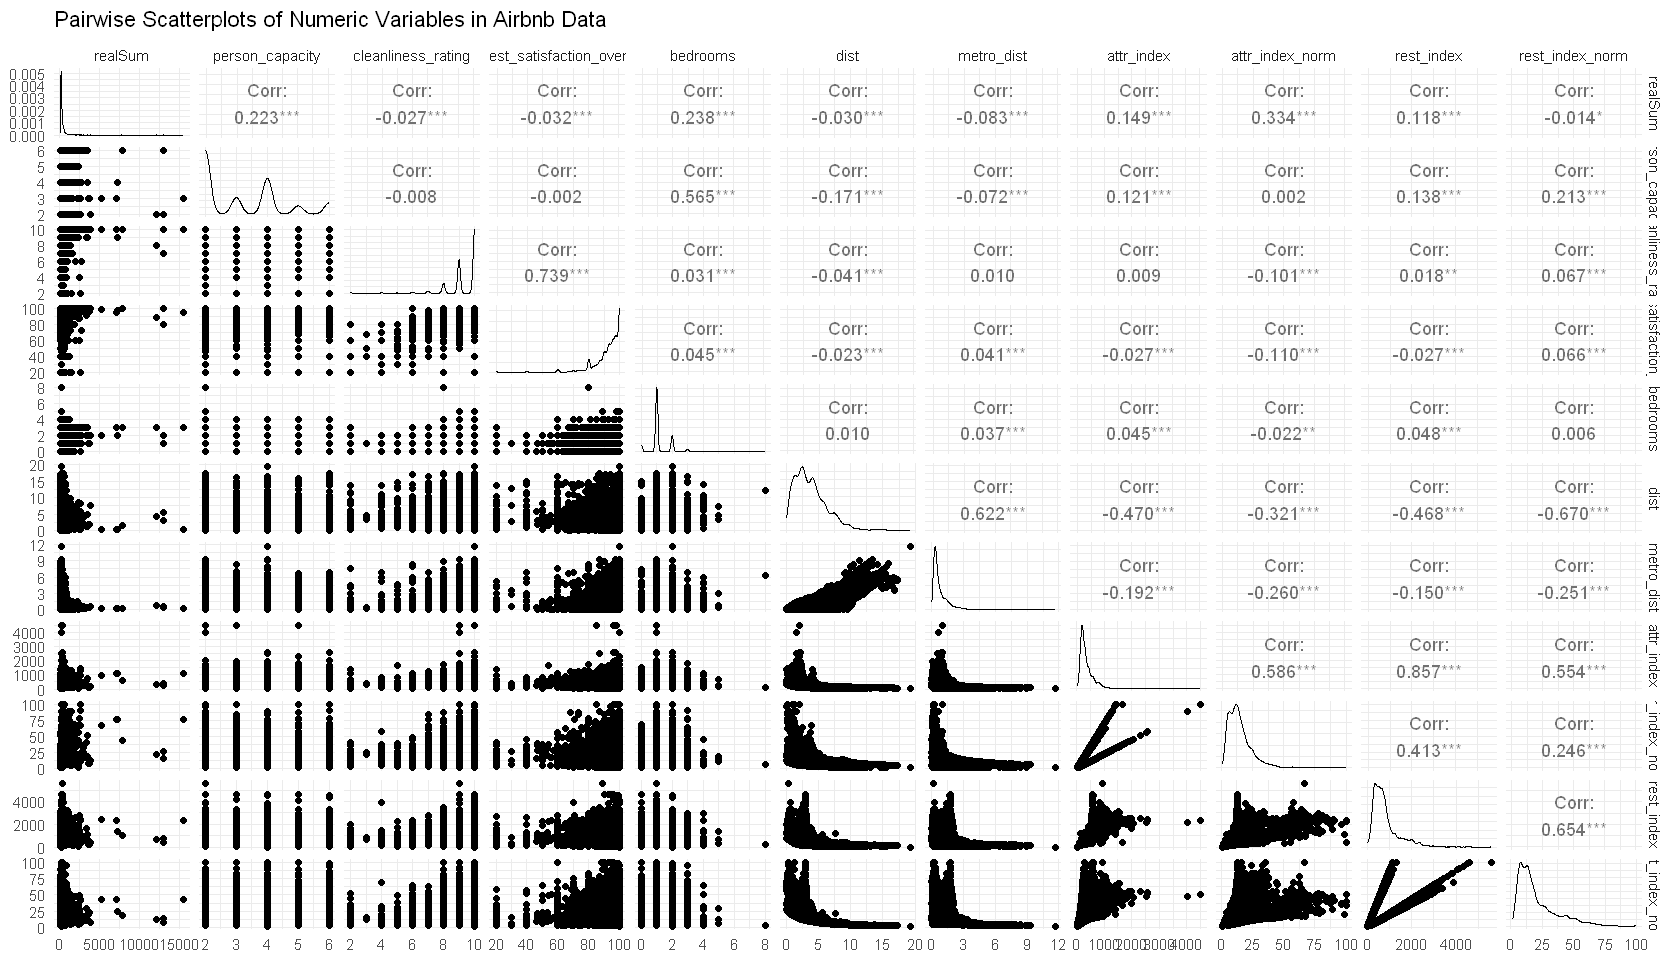

In [12]:
options(repr.plot.width = 14, repr.plot.height = 8)
ggpairs(airbnb_data |>
    select(where(is.numeric)) |>
    select(-c(multi, biz, lat, lng))) +
    theme_minimal() +
    labs(title = "Pairwise Scatterplots of Numeric Variables in Airbnb Data")

Since there are too many variables, I will also visualize using a correlation matrix to identify the strength of the relationships between the numerical variables:

In [13]:
# Create a correlation matrix for numeric variables
correlation_matrix <- cor(airbnb_data |>
    select(where(is.numeric)) |>
    select(-c(multi, biz, lat, lng)), use = "pairwise.complete.obs")

correlation_matrix

,realSum,person_capacity,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm
realSum,1.00000000,0.223083415,-0.027068753,-0.031998742,0.238013093,-0.03024415,-0.082585582,0.148772366,0.333945563,0.11765491,-0.013734029
person_capacity,0.22308341,1.000000000,-0.008340759,-0.002423775,0.564859129,-0.17117532,-0.072239358,0.121206308,0.002499321,0.13819179,0.213492850
cleanliness_rating,-0.02706875,-0.008340759,1.000000000,0.739373689,0.030616388,-0.04103501,0.009741715,0.008897058,-0.100546430,0.01830116,0.067110477
guest_satisfaction_overall,-0.03199874,-0.002423775,0.739373689,1.000000000,0.045161446,-0.02338566,0.040782332,-0.027382241,-0.110042769,-0.02677636,0.065828048
bedrooms,0.23801309,0.564859129,0.030616388,0.045161446,1.000000000,0.01007483,0.036665255,0.044531318,-0.021662362,0.04761038,0.006075428
dist,-0.03024415,-0.171175315,-0.041035015,-0.023385662,0.010074826,1.00000000,0.621768684,-0.470181272,-0.321226139,-0.46755914,-0.670307913
metro_dist,-0.08258558,-0.072239358,0.009741715,0.040782332,0.036665255,0.62176868,1.000000000,-0.192213011,-0.260414556,-0.15013087,-0.250856832
attr_index,0.14877237,0.121206308,0.008897058,-0.027382241,0.044531318,-0.47018127,-0.192213011,1.000000000,0.586057221,0.85653080,0.553571843
attr_index_norm,0.33394556,0.002499321,-0.100546430,-0.110042769,-0.021662362,-0.32122614,-0.260414556,0.586057221,1.000000000,0.41295930,0.246338755
rest_index,0.11765491,0.138191787,0.018301162,-0.026776364,0.047610382,-0.46755914,-0.150130869,0.856530800,0.412959299,1.00000000,0.654083219


But it's still too hard to see the strong correlations, so I filter to only show pairs of variables with an absolute correlation greater than 0.5, and ensure that each pair is shown only once:

In [14]:
# Compute pairwise correlation coefficients
correlation_results <- airbnb_data |>
    select(where(is.numeric), -lat, -lng) |>
    cor(use = "complete.obs") |>
    as.data.frame() |>
    rownames_to_column(var = "Variable1") |>
    pivot_longer(cols = -Variable1, names_to = "Variable2", values_to = "Correlation") |>
    filter(Variable1 < Variable2, abs(Correlation) > 0.5) |> # Ensure each pair is shown only once and report strong correlations
    arrange(desc(abs(Correlation)))

correlation_results

Variable1,Variable2,Correlation
<chr>,<chr>,<dbl>
attr_index,rest_index,0.8565308
cleanliness_rating,guest_satisfaction_overall,0.7393737
dist,rest_index_norm,-0.6703079
rest_index,rest_index_norm,0.6540832
dist,metro_dist,0.6217687
attr_index,attr_index_norm,0.5860572
bedrooms,person_capacity,0.5648591
attr_index,rest_index_norm,0.5535718
biz,multi,-0.5185250


The above correlation matrix shows that there are several pairs of variables with strong correlations, such as `dist` and `attr_index`, `rest_index` and `rest_index_norm`, and `lng` and `lat`. These correlations suggest that these variables may be related to each other and may need to be handled carefully in the modeling process. Which we can use the Variance Inflation Factor (VIF) later to check for multicollinearity.

And while `rest_index` and `rest_index_norm` are not strongly correlated to a threshold of 0.6 absolute correlation coefficient, I realized keeping both indices quantifying the same feature in the model will confound our studies, therefore I will only use the normalized index variable `rest_index_norm`. The same applies to `attr_index` and `attr_index_norm`.

### Task (3) Explanatory Data Analysis and Visualizations

#### Geospatial Visualizations

With the latitude and longitude attributes available in the dataset, I create geospatial visualizations to explore the distribution of Airbnb listings in Budapest, London, and Rome with Stadia Maps api. 

I begin by a creating map to visualize the locations of the listings,  then color-code by city and room type. This will help us understand the geographical distribution of listings and identify any patterns or clusters.

ℹ © Stadia Maps © Stamen Design © OpenMapTiles © OpenStreetMap contributors.

ℹ © Stadia Maps © Stamen Design © OpenMapTiles © OpenStreetMap contributors.

ℹ © Stadia Maps © Stamen Design © OpenMapTiles © OpenStreetMap contributors.



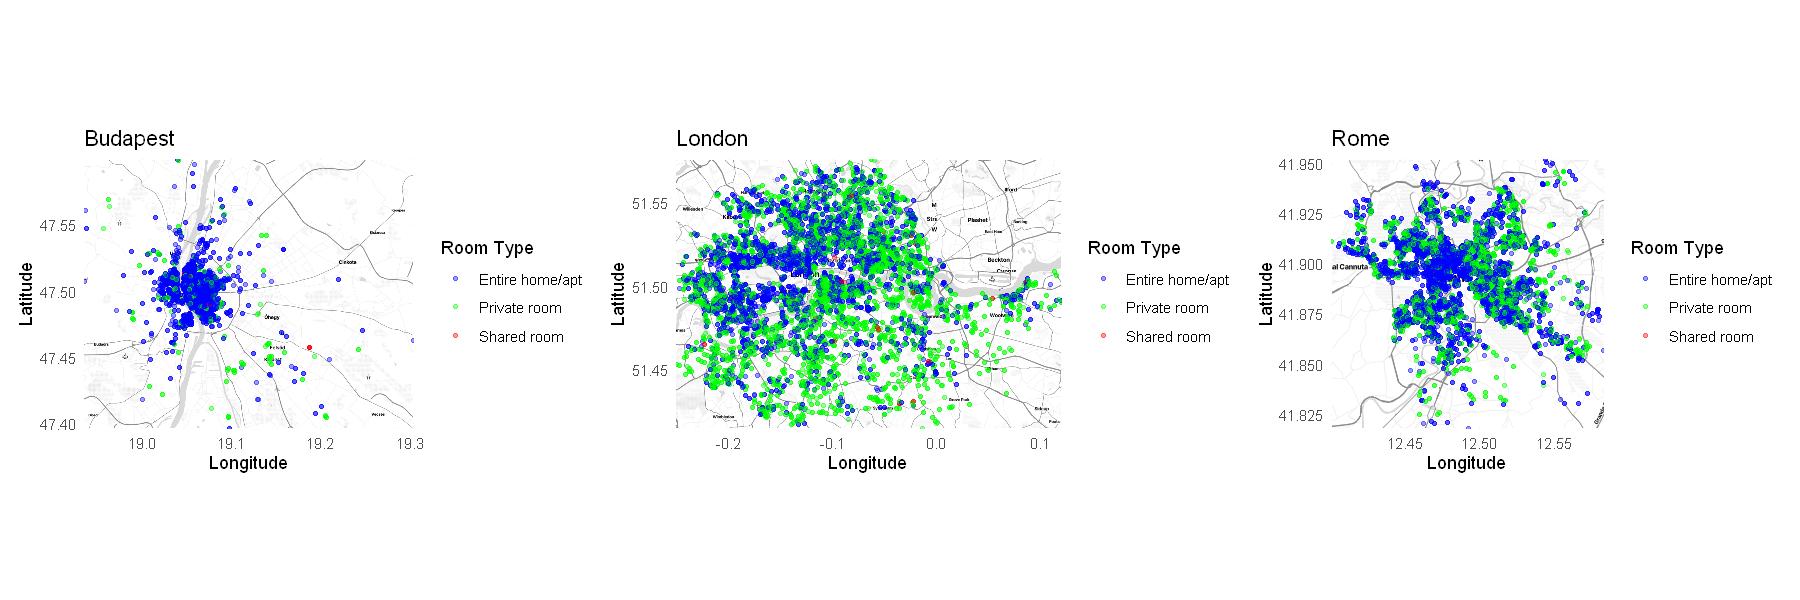

In [15]:
options(repr.plot.width = 15, repr.plot.height = 5)
# Geospatial Visualization of the Budapest, London, and Rome Airbnb listings
register_stadiamaps(key = "0352871b-7427-4059-a925-dec8b550de18")

# Function to generate geospatial visualization for a city
generate_city_map <- function(city_name, airbnb_data) {
  # Get bounding box for the city
  city_bbox <- airbnb_data |>
    filter(city == city_name) |>
    summarise(
      min_lat = min(lat),
      max_lat = max(lat),
      min_lng = min(lng),
      max_lng = max(lng)
    )
  
  # Get the map for the city
  city_map_base <- get_stadiamap(
    bbox = c(
      left = city_bbox$min_lng,
      bottom = city_bbox$min_lat,
      right = city_bbox$max_lng,
      top = city_bbox$max_lat
    ),
    zoom = 12,
    maptype = "stamen_toner_lite"
  )
  
  # Filter data for the city
  city_subset <- airbnb_data |>
    filter(city == city_name)
  
  # Generate the map
  city_geomap <- ggmap(city_map_base) +
    geom_point(data = city_subset, aes(x = lng, y = lat, color = room_type), alpha = 0.4, size = 1) +
    scale_color_manual(values = c("Entire home/apt" = "blue", "Private room" = "green", "Shared room" = "red")) +
    labs(title = str_to_title(city_name), x = "Longitude", y = "Latitude", color = "Room Type") +
    theme_minimal()
  
  return(list(city_geomap = city_geomap, city_map_base = city_map_base))
}

# Generate maps and map bases for Budapest, London, and Rome
budapest_map <- generate_city_map("budapest", airbnb_data)
london_map <- generate_city_map("london", airbnb_data)
rome_map <- generate_city_map("rome", airbnb_data)

# Plot the three maps side by side
budapest_map$city_geomap + london_map$city_geomap + rome_map$city_geomap

We can see from above that the private room listings tend to distribute at the outer areas of the cities, while the entire home/apt listings are more concentrated in the city centers.

Then I create another map to visualize the distributions of total price and overall satisfaction score of Airbnb listings in Budapest, London, and Rome. This will help us understand how these two candiate response variables are distributed geographically and whether there are any noticeable patterns or clusters. Since the `realSum` variable is highly skewed, I use a log-10 transformation to better visualize the distribution of prices.

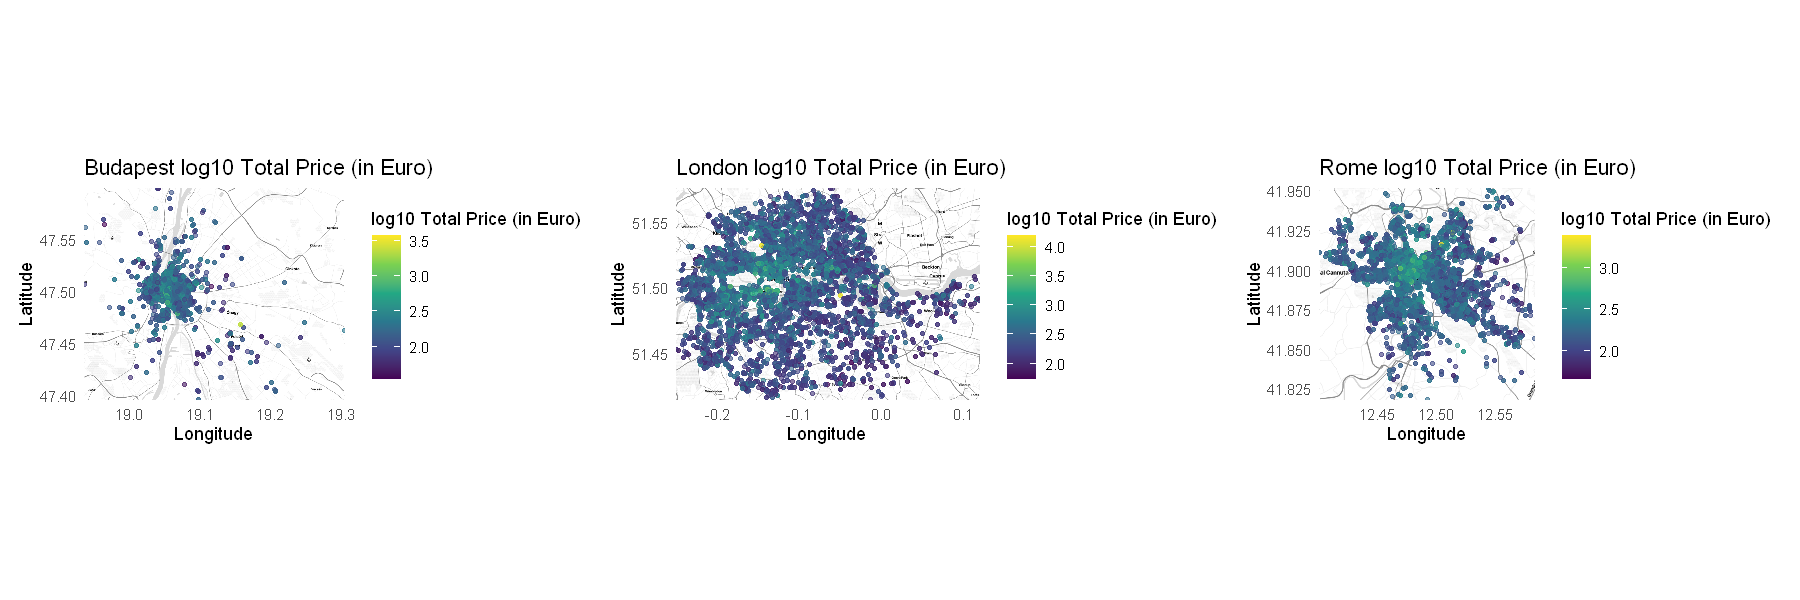

In [16]:
options(repr.plot.width = 15, repr.plot.height = 5)

# Plot the distribution of total price on maps
make_price_map <- function(map_base, city_name) {
  ggmap(map_base) +
    geom_point(
      data  = airbnb_data |> filter(city == city_name),
      aes(x = lng, y = lat, color = log10(realSum)),
      alpha = 0.6,
      size  = 1
    ) +
    scale_color_viridis_c(name = "log10 Total Price (in Euro)") +
    labs(
      title = paste0(str_to_title(city_name), " log10 Total Price (in Euro)"),
      x     = "Longitude",
      y     = "Latitude"
    ) +
    theme_minimal()
}

budapest_price_map <- make_price_map(budapest_map$city_map_base, "budapest")
london_price_map <- make_price_map(london_map$city_map_base, "london")
rome_price_map <- make_price_map(rome_map$city_map_base, "rome")

# Display the three maps side by side
budapest_price_map + london_price_map + rome_price_map

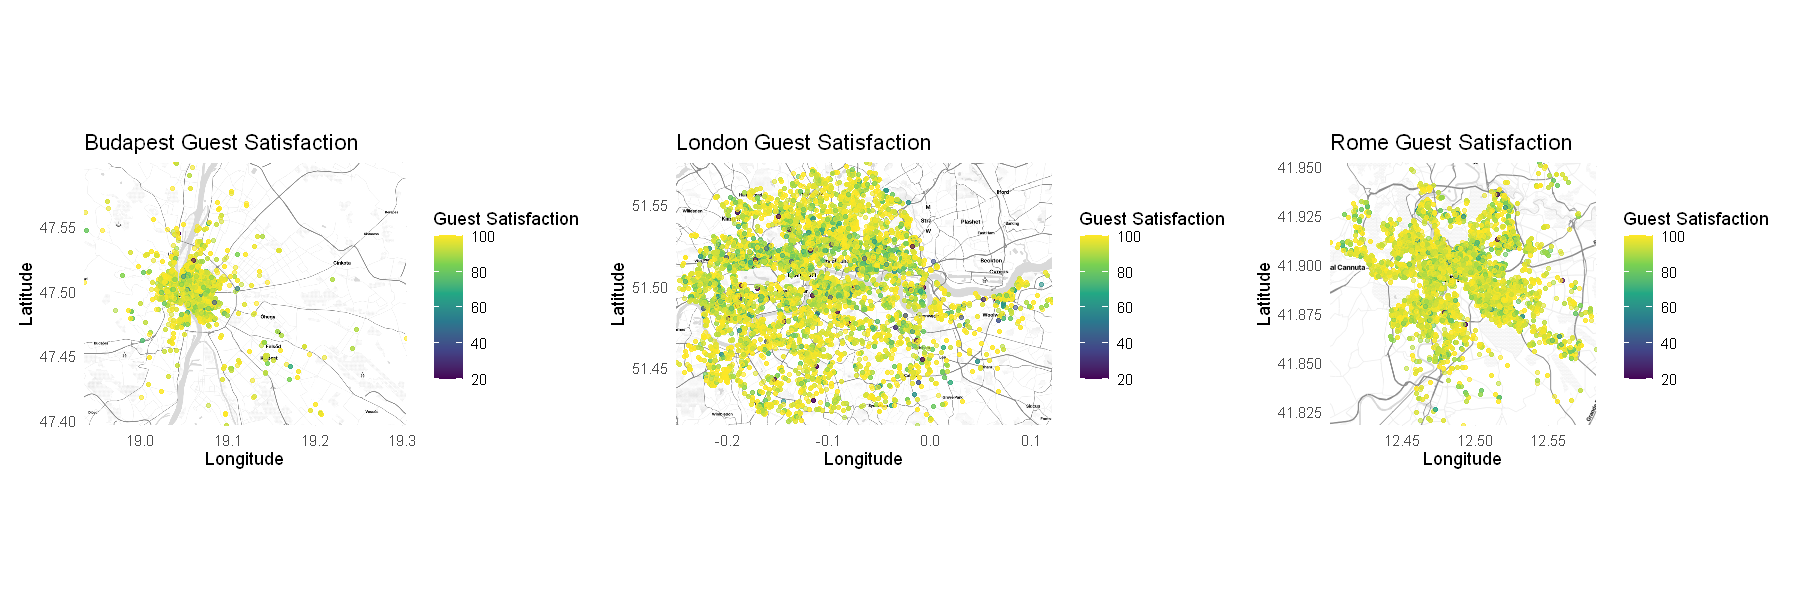

In [17]:
options(repr.plot.width = 15, repr.plot.height = 5)

# Plot the distribution of satisfaction on maps
make_satisfaction_map <- function(map_base, city_name) {
  ggmap(map_base) +
    geom_point(
      data  = airbnb_data |> filter(city == city_name),
      aes(x = lng, y = lat, color = guest_satisfaction_overall),
      alpha = 0.6,
      size  = 1
    ) +
    scale_color_viridis_c(name = "Guest Satisfaction") +
    labs(
      title = paste0(str_to_title(city_name), " Guest Satisfaction"),
      x     = "Longitude",
      y     = "Latitude"
    ) +
    theme_minimal()
}

budapest_sat_map <- make_satisfaction_map(budapest_map$city_map_base, "budapest")
london_sat_map <- make_satisfaction_map(london_map$city_map_base, "london")
rome_sat_map <- make_satisfaction_map(rome_map$city_map_base, "rome")

# Display the three maps side by side
budapest_sat_map + london_sat_map + rome_sat_map

While there isn't a clear pattern in the distribution of overall satisfaction scores, we can see that the total price of listings is generally higher in the city centers. This suggests that location plays a significant role in determining the price of Airbnb listings.

To confirm this hypothesis, I create the scatter plot below to visualize the relationship between the distance from the city center and the total price of listings in Budapest, London, and Rome. This will help us understand how the distance from the city center affects the price of Airbnb listings.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


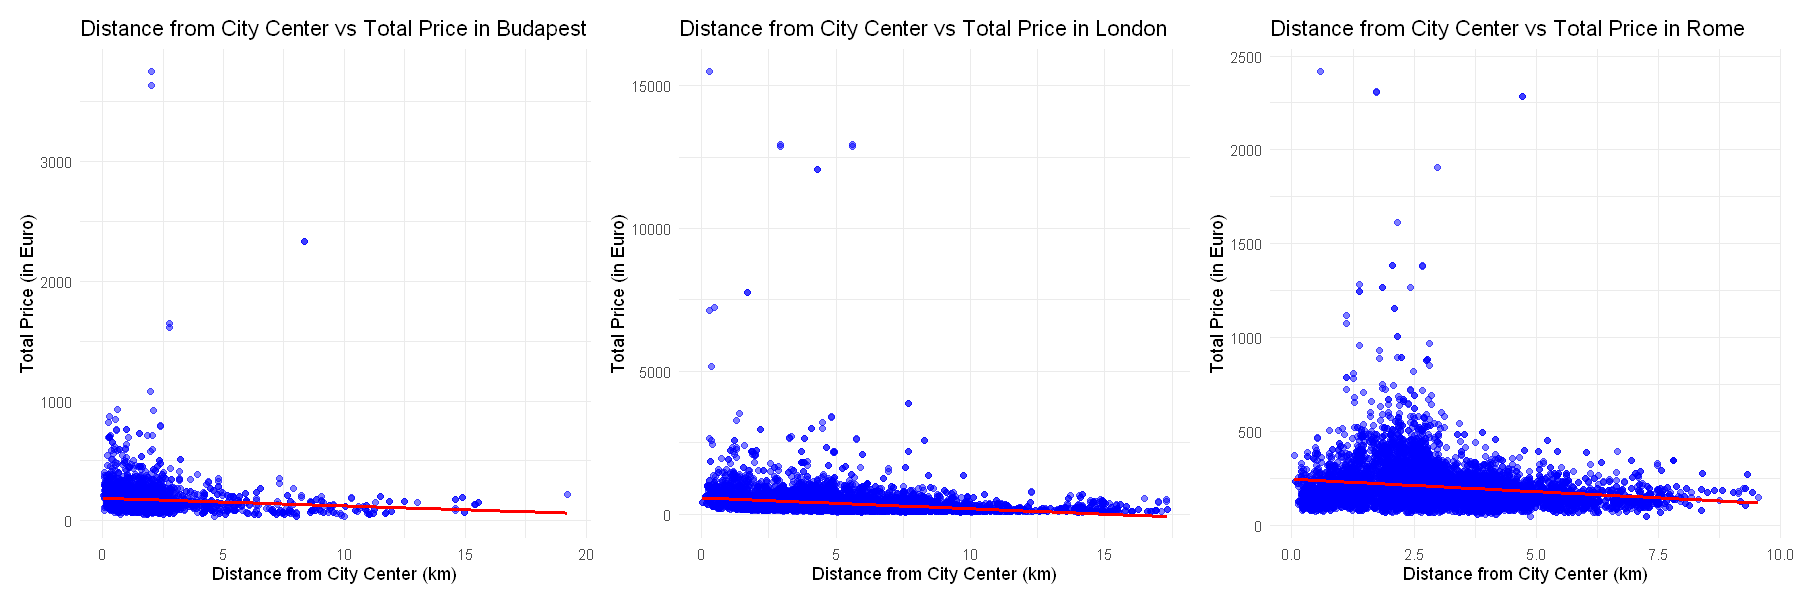

In [18]:
# Visualize the relationship between distance from city center and total price
options(repr.plot.width = 15, repr.plot.height = 5)
make_distance_price_scatter <- function(city_name) {
  ggplot(airbnb_data |> filter(city == city_name), aes(x = dist, y = realSum)) +
    geom_point(alpha = 0.5, color = "blue") +
    geom_smooth(method = "lm", color = "red", se = FALSE) +
    labs(
      title = paste0("Distance from City Center vs Total Price in ", str_to_title(city_name)),
      x     = "Distance from City Center (km)",
      y     = "Total Price (in Euro)"
    ) +
    theme_minimal()
}

budapest_distance_price <- make_distance_price_scatter("budapest")
london_distance_price <- make_distance_price_scatter("london")
rome_distance_price <- make_distance_price_scatter("rome")

# Display the scatter plots side by side
budapest_distance_price + london_distance_price + rome_distance_price

We also visualize the distance to city centers from the listings on a map, which shows the distance from the city center for each listing in Budapest, London, and Rome. This will help us understand the recognized location of the city center in each city and how it relates to the listings' locations.

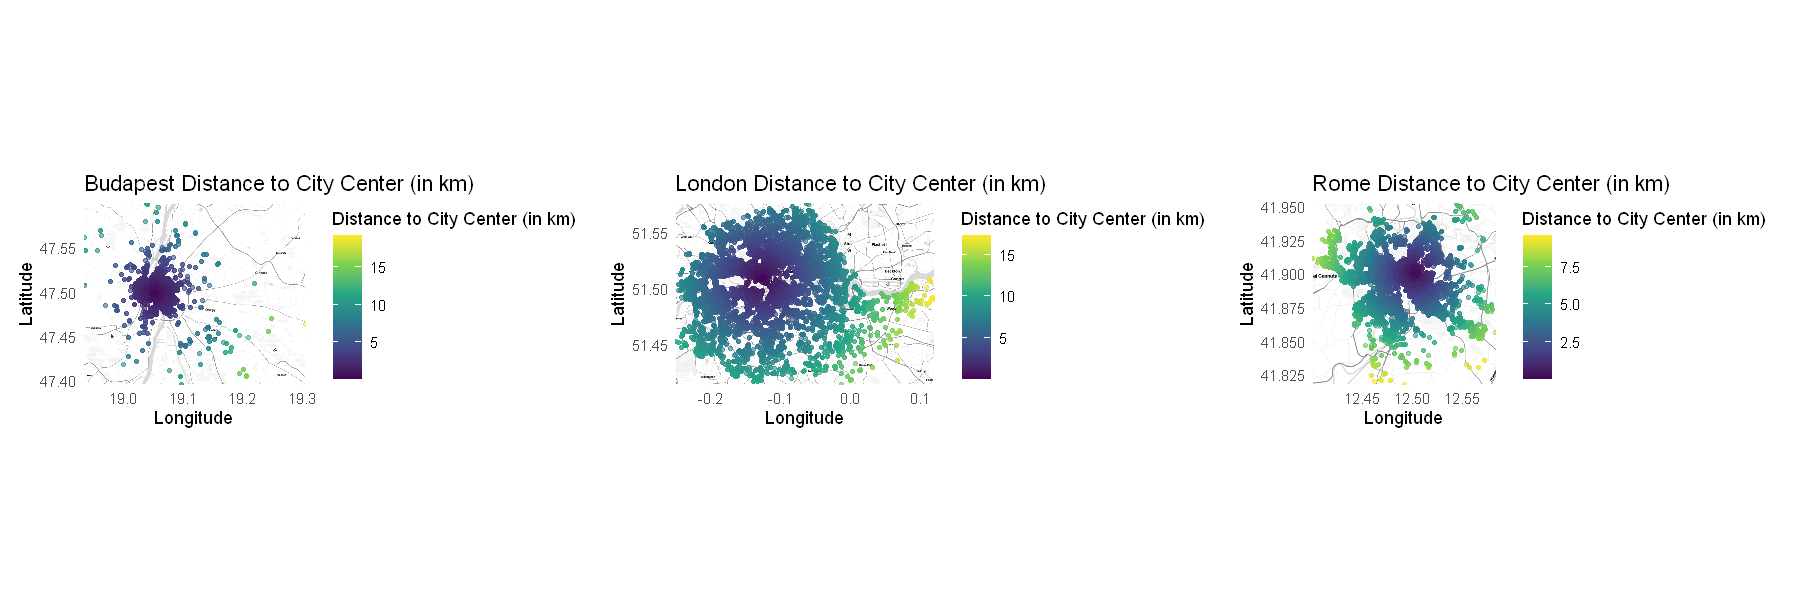

In [19]:
options(repr.plot.width = 15, repr.plot.height = 5)
# Visualize the distance to city center from the listings on  a map
make_distance_map <- function(map_base, city_name) {
    ggmap(map_base) +
        geom_point(
        data  = airbnb_data |> filter(city == city_name),
        aes(x = lng, y = lat, color = dist),
        alpha = 0.6,
        size  = 1
        ) +
        scale_color_viridis_c(name = "Distance to City Center (in km)") +
        labs(
        title = paste0(str_to_title(city_name), " Distance to City Center (in km)"),
        x     = "Longitude",
        y     = "Latitude"
        ) +
        theme_minimal()
    }

budapest_dist_map <- make_distance_map(budapest_map$city_map_base, "budapest")
london_dist_map <- make_distance_map(london_map$city_map_base, "london")
rome_dist_map <- make_distance_map(rome_map$city_map_base, "rome")

# Display the three maps side by side
budapest_dist_map + london_dist_map + rome_dist_map

Similarly, I create a visualization of the distance to metro stations from the listings on a map, and plot the scatter plots of the distance to metro stations against the total price of listings in Budapest, London, and Rome. This will help us understand how the distance to metro stations affects the price of Airbnb listings.

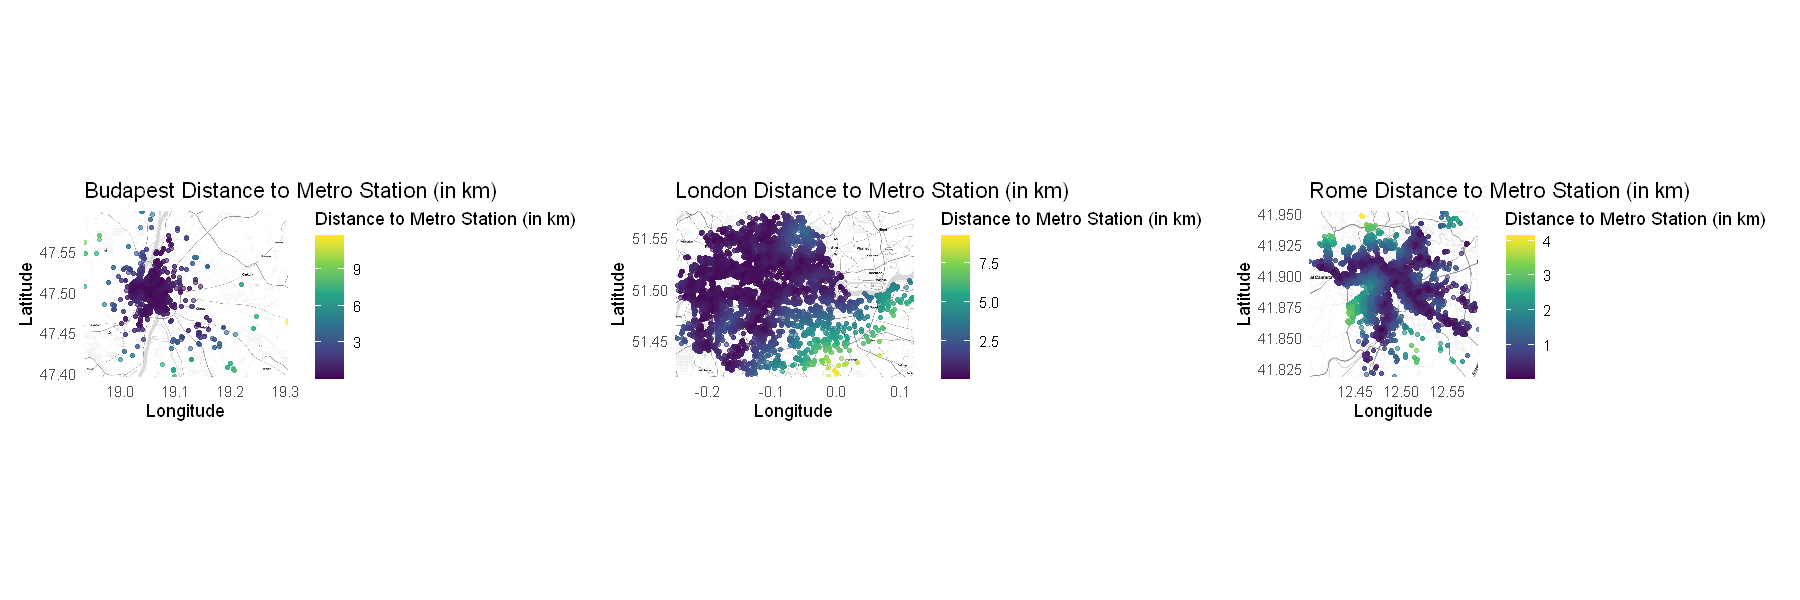

In [20]:
# Visualize the distance to metro stations
make_metro_map <- function(map_base, city_name) {
    ggmap(map_base) +
        geom_point(
        data  = airbnb_data |> filter(city == city_name),
        aes(x = lng, y = lat, color = metro_dist),
        alpha = 0.6,
        size  = 1
        ) +
        scale_color_viridis_c(name = "Distance to Metro Station (in km)") +
        labs(
        title = paste0(str_to_title(city_name), " Distance to Metro Station (in km)"),
        x     = "Longitude",
        y     = "Latitude"
        ) +
        theme_minimal()
    }

budapest_metro_map <- make_metro_map(budapest_map$city_map_base, "budapest")
london_metro_map <- make_metro_map(london_map$city_map_base, "london")
rome_metro_map <- make_metro_map(rome_map$city_map_base, "rome")

# Display the three maps side by side
budapest_metro_map + london_metro_map + rome_metro_map

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


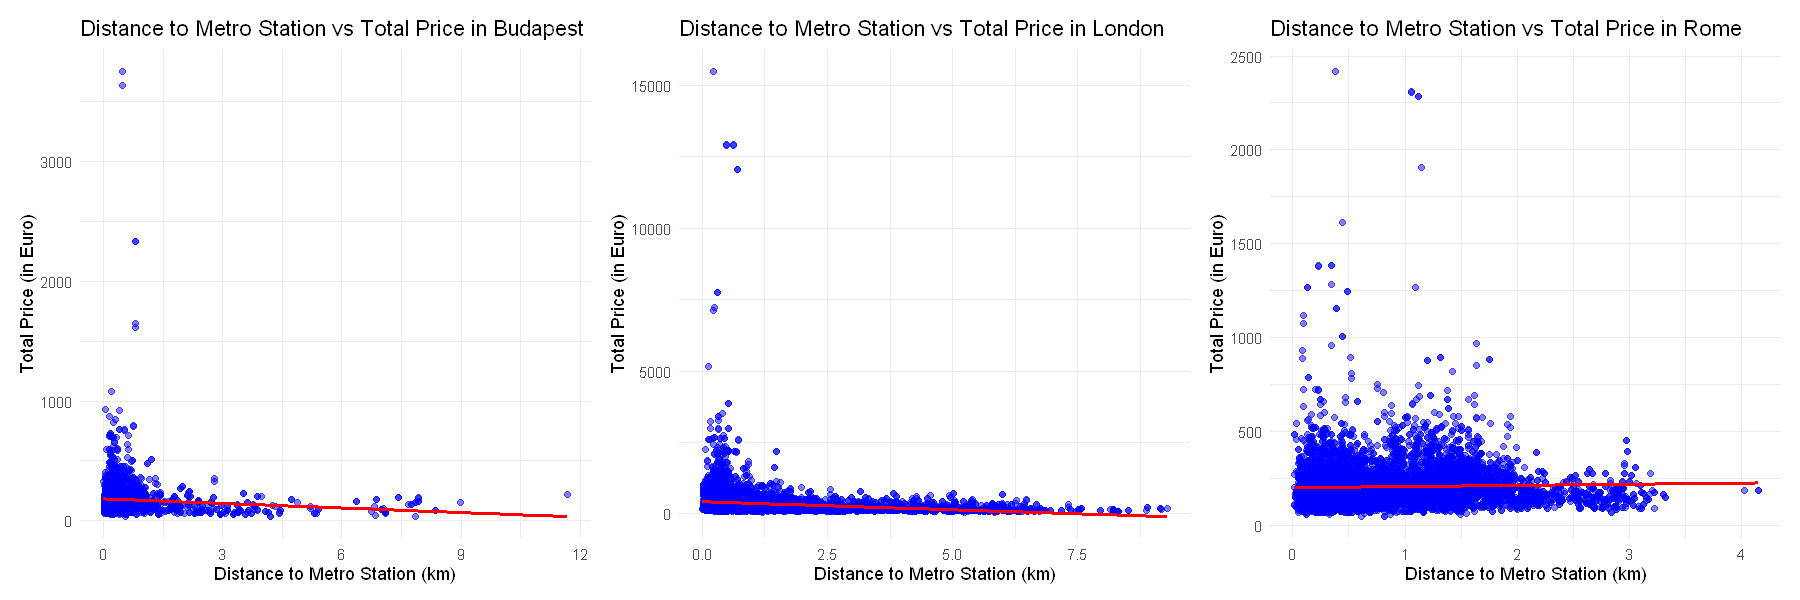

In [21]:
# Plot the scatter plots of distance to metro stations against total price
make_metro_price_scatter <- function(city_name) {
    ggplot(airbnb_data |> filter(city == city_name), aes(x = metro_dist, y = realSum)) +
        geom_point(alpha = 0.5, color = "blue") +
        geom_smooth(method = "lm", color = "red", se = FALSE) +
        labs(
        title = paste0("Distance to Metro Station vs Total Price in ", str_to_title(city_name)),
        x     = "Distance to Metro Station (km)",
        y     = "Total Price (in Euro)"
        ) +
        theme_minimal()
    }

budapest_metro_price <- make_metro_price_scatter("budapest")
london_metro_price <- make_metro_price_scatter("london")    
rome_metro_price <- make_metro_price_scatter("rome")

# Display the scatter plots side by side
budapest_metro_price + london_metro_price + rome_metro_price

#### Testing Response Candidate: `realSum`

With the two candidate response variables identified, I will first focus on the total price of listings (`realSum`) as the response variable. The first thing I want to confirm is whether we have enough evidence that the total price of listings is significantly different for different cities, weekday or weekend and room types. To do this, I will perform a series of statistical tests and visualizations. With `realSum` scaled by log-10 for better visual representations.

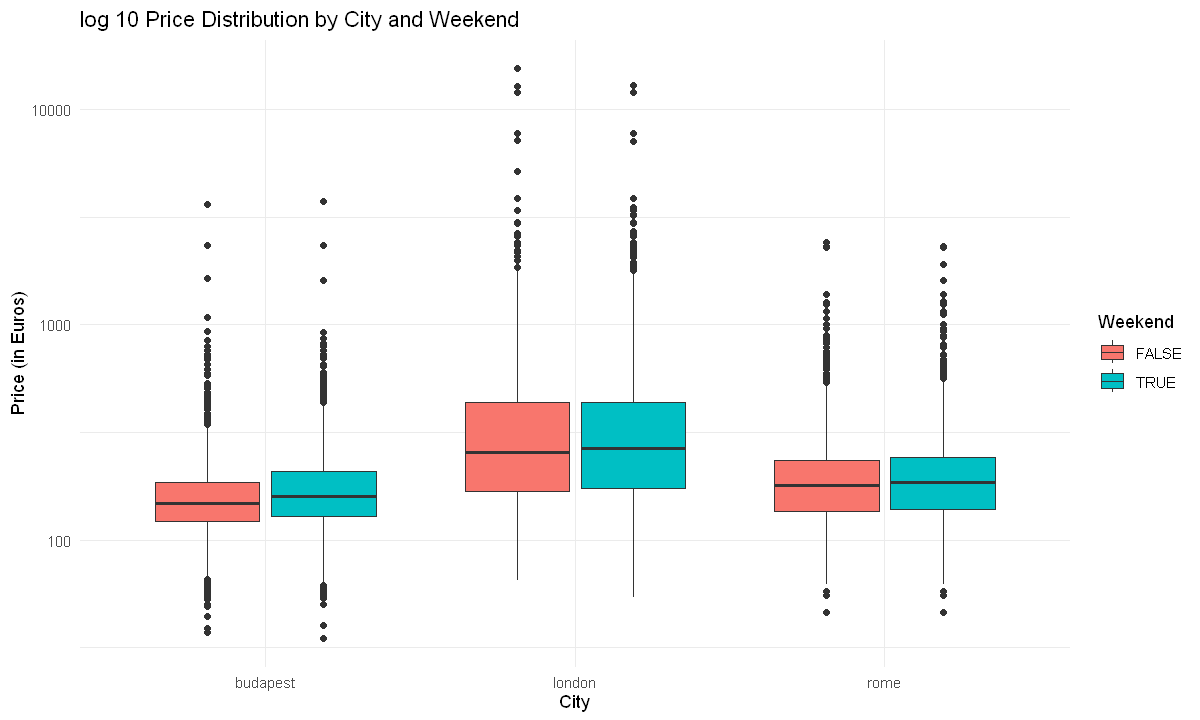

In [22]:
options(repr.plot.width=10, repr.plot.height=6)
# Create box plots for price distribution by city and weekend
price_boxplot <- ggplot(airbnb_data, aes(x = city, y = realSum, fill = weekend)) +
    geom_boxplot() +
    scale_y_log10() + 
    labs(title = "log 10 Price Distribution by City and Weekend", x = "City", y = "Price (in Euros)", fill = "Weekend") +
    theme_minimal()

price_boxplot

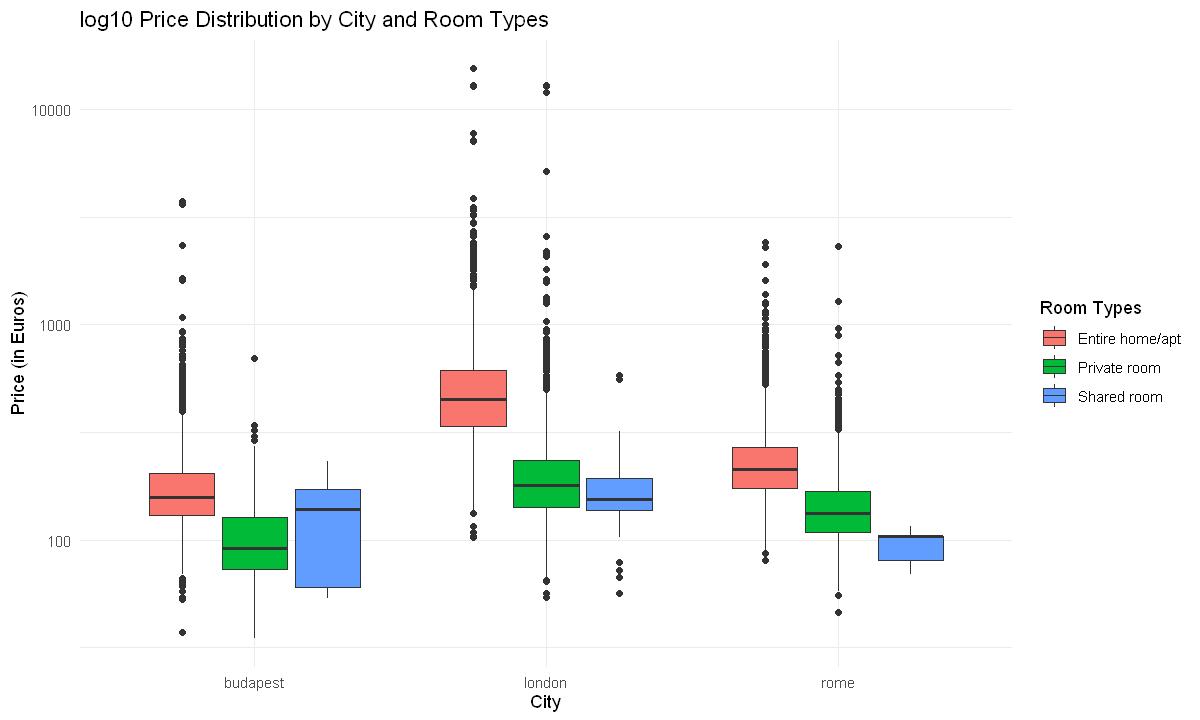

In [23]:
# Create the box plot showing the price distribution of 3 different room types
price_boxplot <- ggplot(airbnb_data, aes(x = city, y = realSum, fill = room_type)) +
    geom_boxplot() +
    scale_y_log10() + 
    labs(title = "log10 Price Distribution by City and Room Types", x = "City", y = "Price (in Euros)", fill = "Room Types") +
    theme_minimal()

price_boxplot

We test the hypothesis of different cities with a one way ANOVA test and the result is shown below:

In [24]:
# anova for price differences between cities
anova_price_city <- aov(realSum ~ city, data = airbnb_data)
summary(anova_price_city)

               Df    Sum Sq  Mean Sq F value Pr(>F)    
city            2 1.582e+08 79111865   754.4 <2e-16 ***
Residuals   23039 2.416e+09   104872                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

We confirmed that there is a significant difference in the total price of listings between different cities, with a p-value less than 0.05.

Then we use a t-test to test the hypothesis of weekday  or weekend listings, and the result is shown below:

In [25]:
# t-test for price differences between weekends and weekdays
t_test_price_weekend <- t.test(realSum ~ weekend, data = airbnb_data)

t_test_price_weekend


	Welch Two Sample t-test

data:  realSum by weekend
t = -3.3218, df = 22544, p-value = 0.0008959
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -23.328351  -6.014207
sample estimates:
mean in group FALSE  mean in group TRUE 
           260.9207            275.5920 


Still, we confirmed that there is a significant difference in the total price of listings between weekday and weekend listings, with a p-value less than 0.05.

Then we proceed to test the hypothesis of different room types with a one way ANOVA test, and the result is shown below:

In [26]:
# anova for price differences between room types
anova_price_room_type <- aov(realSum ~ room_type, data = airbnb_data)
summary(anova_price_room_type)

               Df    Sum Sq  Mean Sq F value Pr(>F)    
room_type       2 1.024e+08 51192014   477.1 <2e-16 ***
Residuals   23039 2.472e+09   107296                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Still, I confirmed that there is a significant difference in the total price of listings between weekday and weekend listings, with a p-value less than 0.05.

I then do the same thing to `multi` and `biz` variables.

In [27]:
# t-test for price differences between multi and non-multi listings
t_test_price_multi <- t.test(realSum ~ multi, data = airbnb_data)

t_test_price_multi


	Welch Two Sample t-test

data:  realSum by multi
t = 11.372, df = 22145, p-value < 2.2e-16
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 37.13030 52.59567
sample estimates:
mean in group 0 mean in group 1 
       282.9826        238.1196 


In [28]:
# t-test for price difference between iz and non-biz listings
t_test_price_biz <- t.test(realSum ~ biz, data = airbnb_data)

t_test_price_biz 


	Welch Two Sample t-test

data:  realSum by biz
t = -11.422, df = 19063, p-value < 2.2e-16
alternative hypothesis: true difference in means between group 0 and group 1 is not equal to 0
95 percent confidence interval:
 -59.08715 -41.77770
sample estimates:
mean in group 0 mean in group 1 
       250.3181        300.7505 


The results confrimed that there is a significant difference in the total price of listings between multi and non-multi listings, with a p-value less than 0.05, and also between biz and non-biz listings, with a p-value less than 0.05.

To sum up, I group the data by `city` and `weekend` for another summary.

In [29]:
# Summary statistics of the candidate response variables: total price 'realSum' and overall satisfaction 'guest_satisfaction_overall'
response_summary <- airbnb_data |>
    group_by(city, weekend) |>
    summarize(
        total_listings = n(),
        avg_price = mean(realSum, na.rm = TRUE),
        max_price = max(realSum, na.rm = TRUE),
        min_price = min(realSum, na.rm = TRUE),
        price_quantile_005 = quantile(realSum, 0.005, na.rm = TRUE),
        price_quantile_995 = quantile(realSum, 0.995, na.rm = TRUE),
        avg_satisfaction = mean(guest_satisfaction_overall, na.rm = TRUE),
        max_satisfaction = max(guest_satisfaction_overall, na.rm = TRUE),
        min_satisfaction = min(guest_satisfaction_overall, na.rm = TRUE),
        satisfaction_quantile_005 = quantile(guest_satisfaction_overall, 0.005, na.rm = TRUE),
        satisfaction_quantile_995 = quantile(guest_satisfaction_overall, 0.995, na.rm = TRUE)
    )

response_summary

`summarise()` has grouped output by 'city'. You can override using the
`.groups` argument.


city,weekend,total_listings,avg_price,max_price,min_price,price_quantile_005,price_quantile_995,avg_satisfaction,max_satisfaction,min_satisfaction,satisfaction_quantile_005,satisfaction_quantile_995
<fct>,<lgl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
budapest,FALSE,2074,168.4294,3630.681,37.12929,54.45552,710.2540,94.52700,100,20,60,100
budapest,TRUE,1948,185.1206,3751.234,34.77934,56.80665,716.4861,94.64733,100,20,60,100
london,FALSE,4614,360.2303,15499.894,64.67697,80.19944,2199.9483,90.32445,100,20,20,100
london,TRUE,5379,364.3897,12937.275,54.32865,79.96425,2192.1306,90.92117,100,20,20,100
rome,FALSE,4492,201.6181,2418.348,46.05709,69.20253,723.9485,93.20013,100,20,60,100
rome,TRUE,4535,209.1301,2311.739,46.05709,69.43633,693.1148,93.04520,100,20,60,100


It is also essential to understand how price distribute across different cities, so I create a list of histograms below:

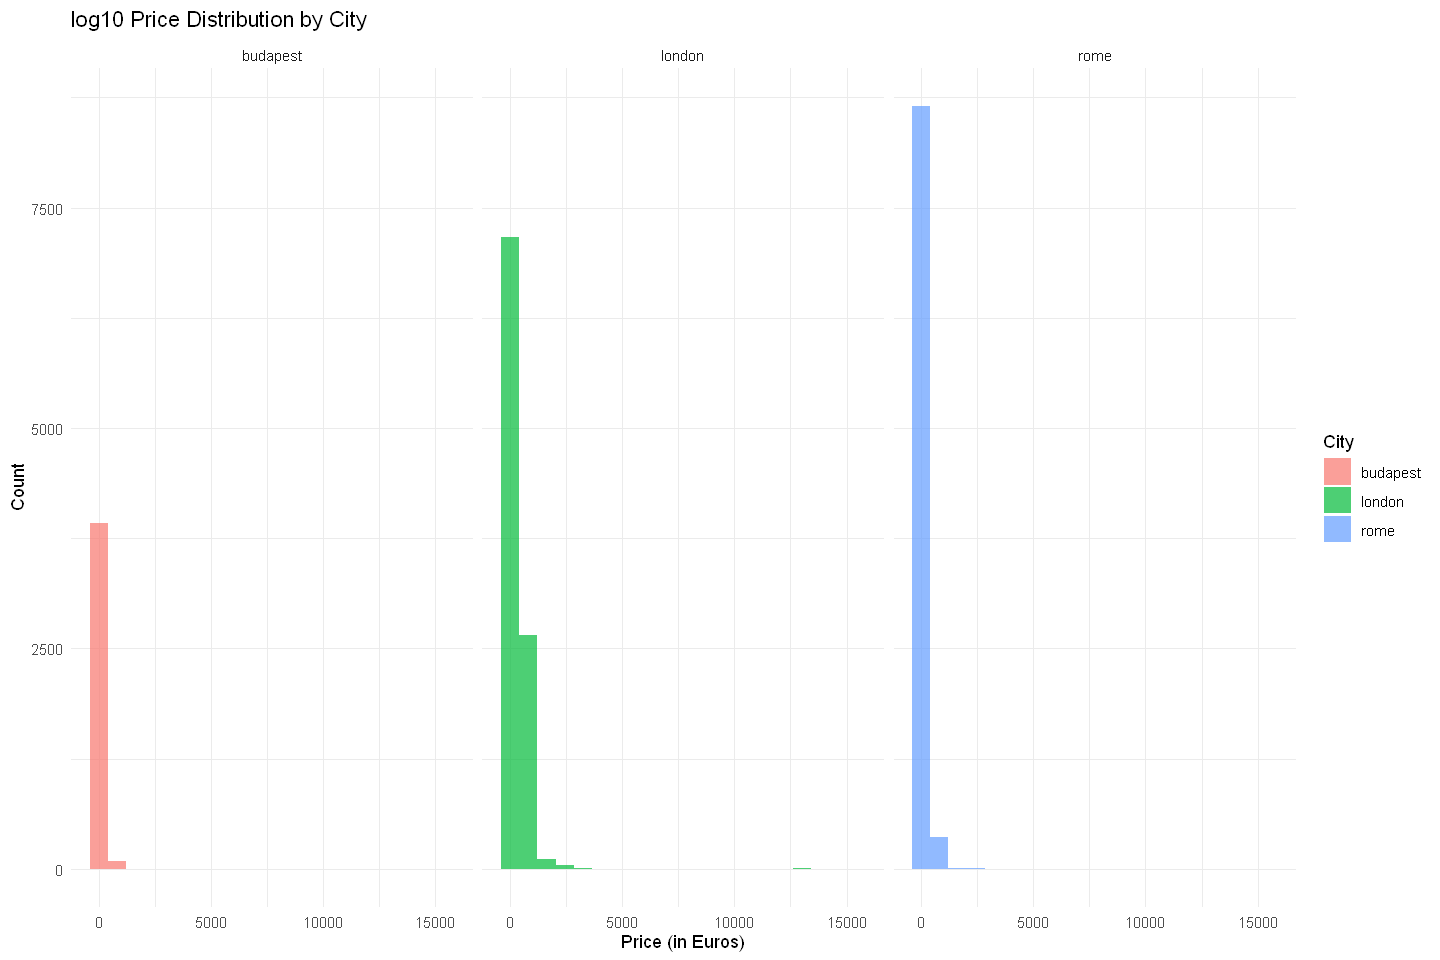

In [30]:
options(repr.plot.width = 12, repr.plot.height = 8)
# Visualize the distribution of price across cities with separate plots
price_distribution <- ggplot(airbnb_data, aes(x = realSum, fill = city)) +
    geom_histogram(bins = 20, alpha = 0.7) +
    facet_wrap(~ city, ncol = 3) +
    labs(title = "log10 Price Distribution by City", x = "Price (in Euros)", y = "Count", fill = "City") +
    theme_minimal()

price_distribution

The visualizations using the raw total price variables are not very informative, so I use the log-10 transformed total price variable to create histograms below:

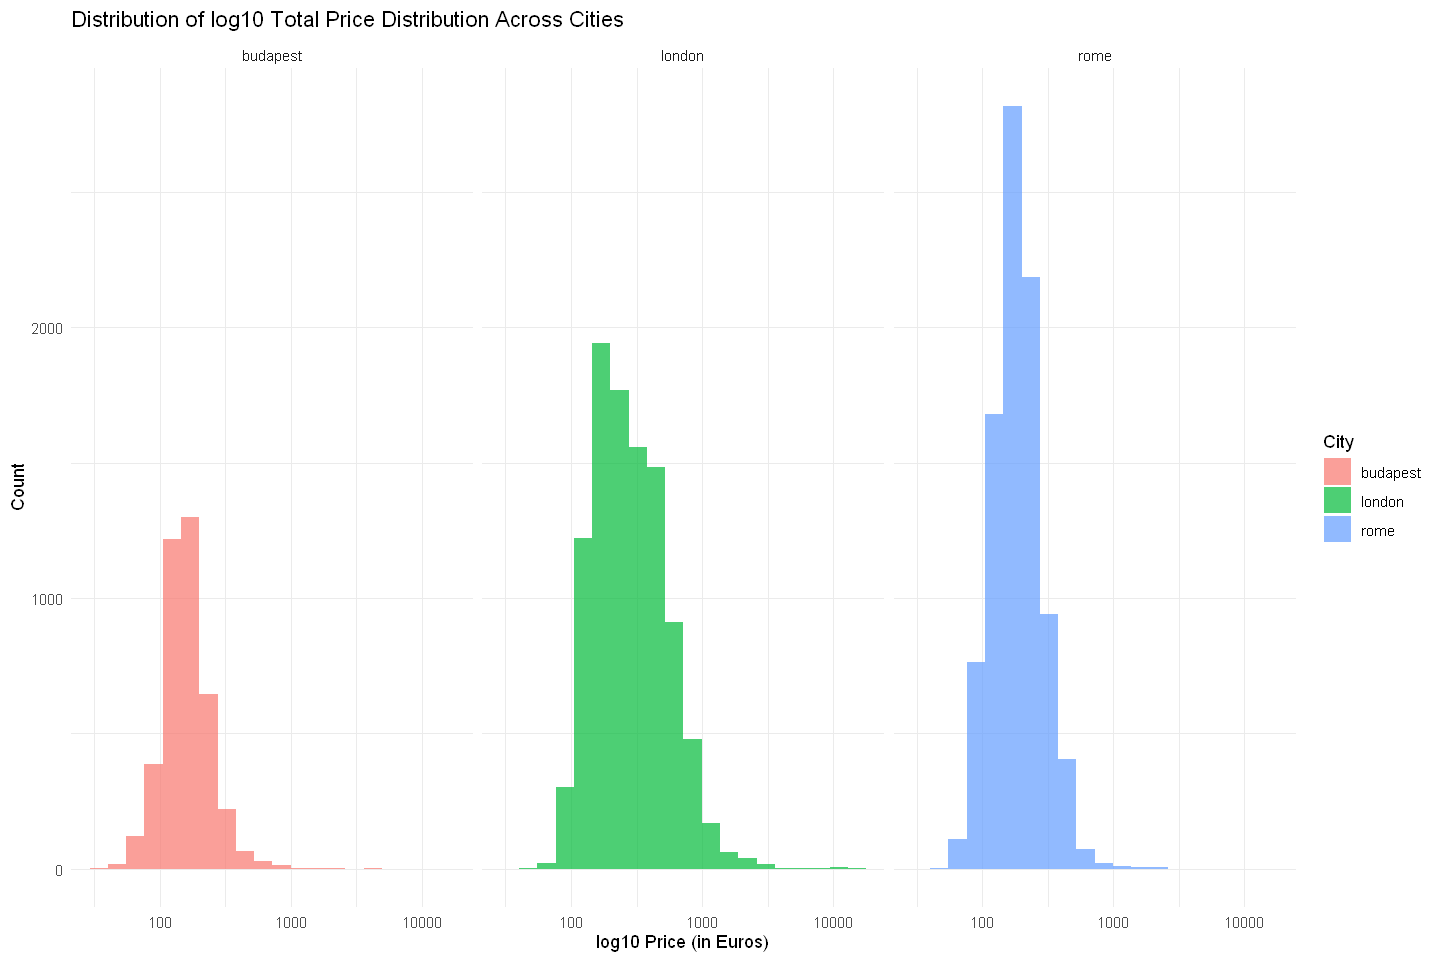

In [31]:
# Visualize the distribution of prices across cities with separate plots
log10_price_distribution <- ggplot(airbnb_data, aes(x = realSum, fill = city)) +
    geom_histogram(bins = 20, alpha = 0.7) +
    scale_x_log10() +
    facet_wrap(~ city, ncol = 3) +
    labs(title = "Distribution of log10 Total Price Distribution Across Cities", x = "log10 Price (in Euros)", y = "Count", fill = "City") +
    theme_minimal()

log10_price_distribution

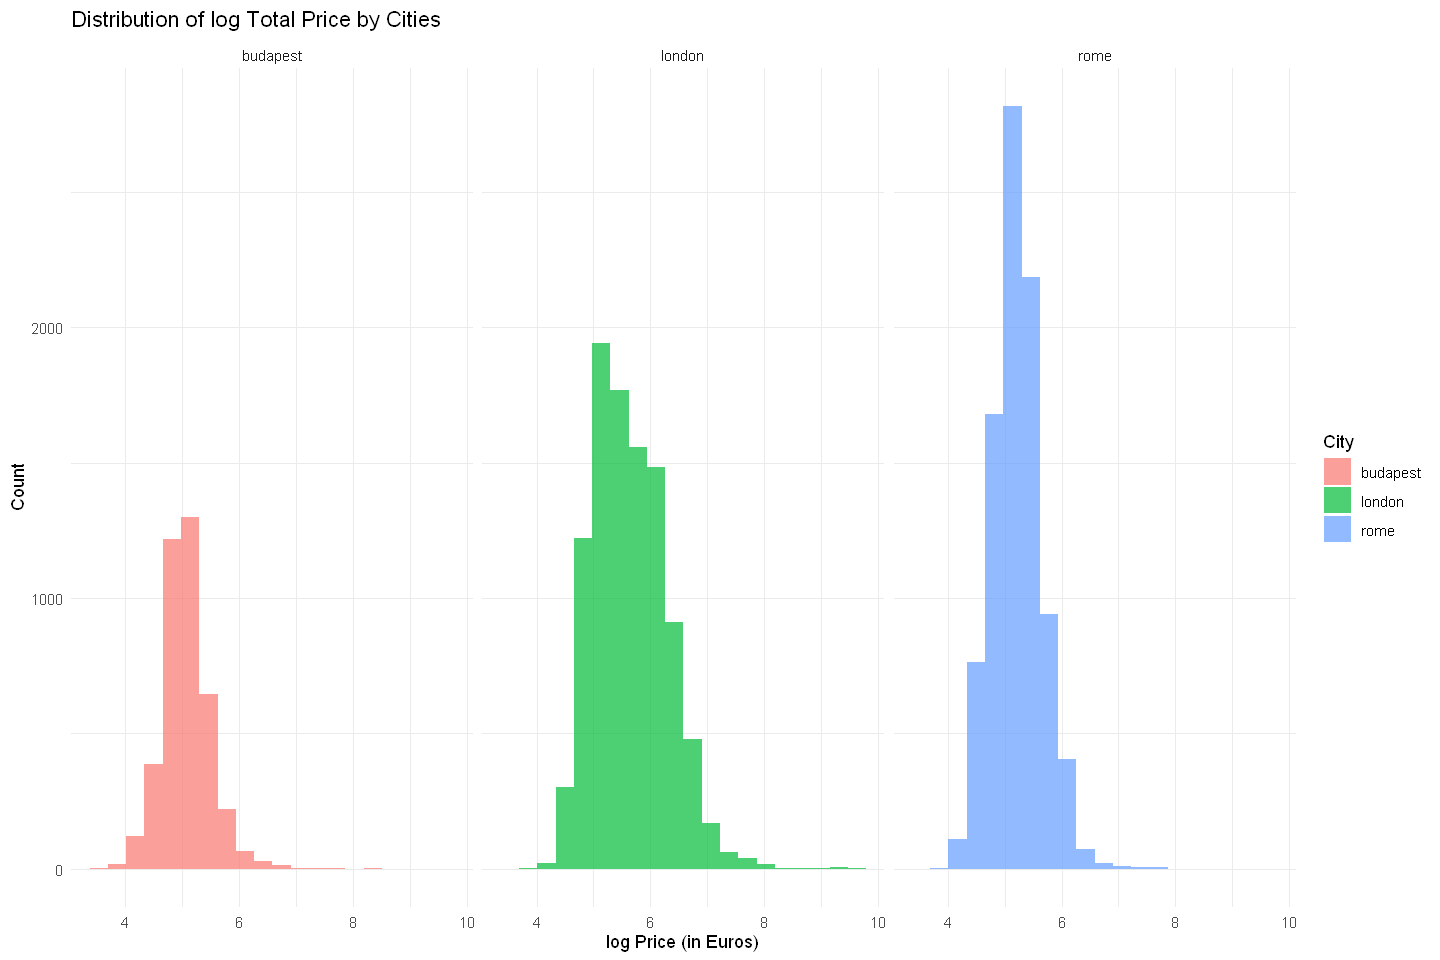

In [32]:
# Visualize the log distribution of prices by cities
log_price_distribution_cities <- ggplot(airbnb_data, aes(x = log(realSum), fill = city)) +
    geom_histogram(bins = 20, alpha = 0.7) +
    facet_wrap(~ city, ncol = 3) +
    labs(title = "Distribution of log Total Price by Cities", x = "log Price (in Euros)", y = "Count", fill = "City") +
    theme_minimal()
    
log_price_distribution_cities

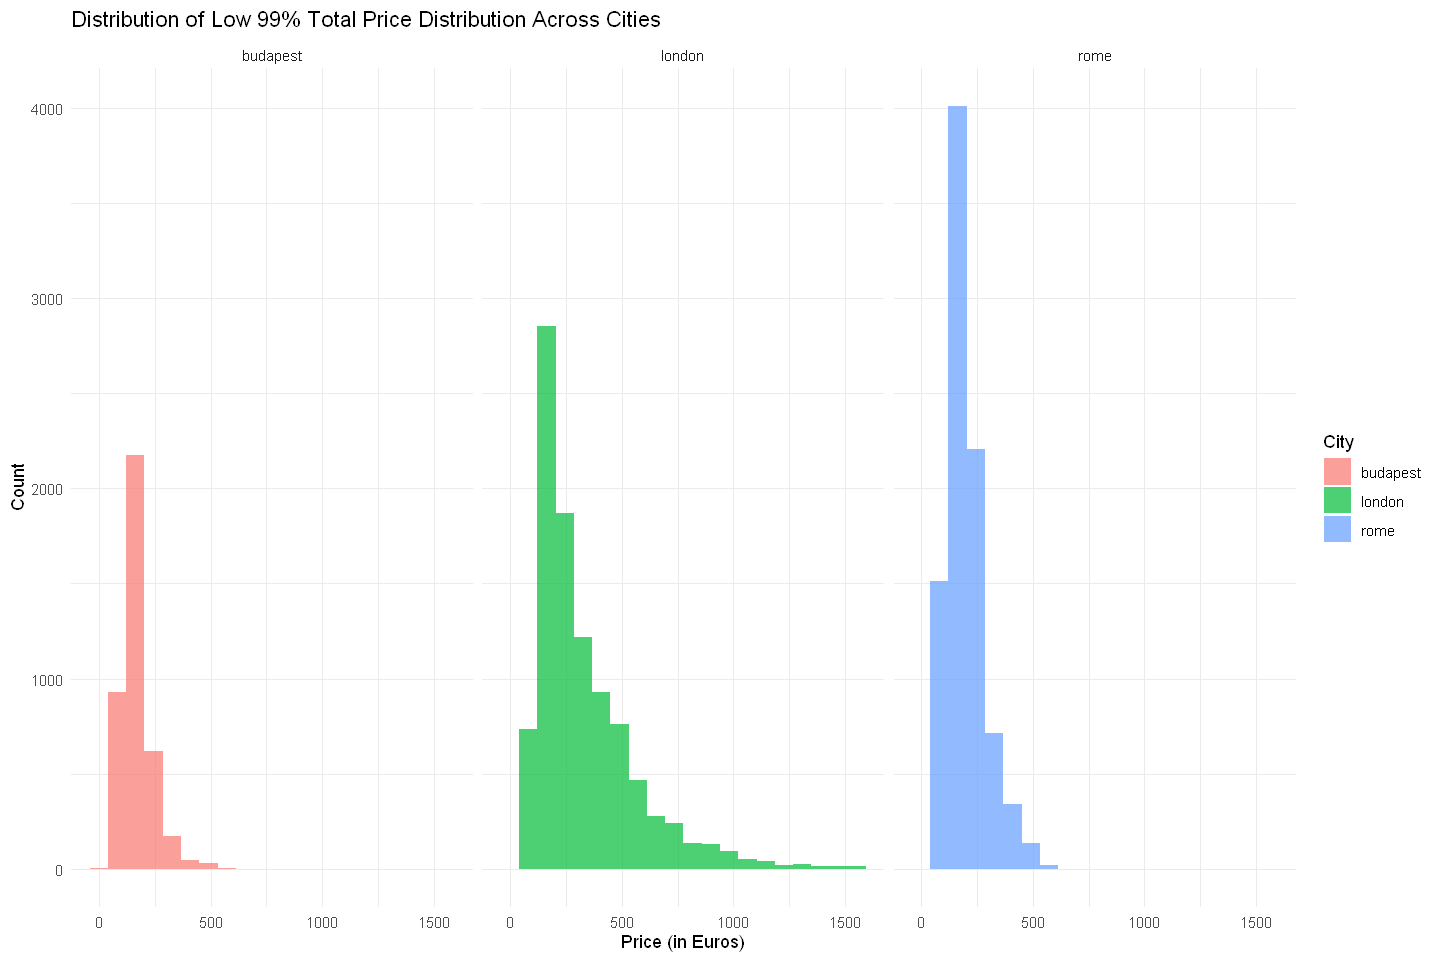

In [33]:
# We visualize the distribution of prices across cities
# focusing on the low 99% of the price distribution to avoid extreme outliers skewing the results
price_99_distribution <- airbnb_data|>
    group_by(city)|>
    filter(realSum < quantile(realSum, 0.99, na.rm = TRUE)) |>
    ungroup()|>
    ggplot(aes(x = realSum, fill = city)) +
    geom_histogram(bins = 20, alpha = 0.7) +
    facet_wrap(~ city, ncol = 3) +
    labs(title = "Distribution of Low 99% Total Price Distribution Across Cities", x = "Price (in Euros)", y = "Count", fill = "City") +
    theme_minimal()

price_99_distribution

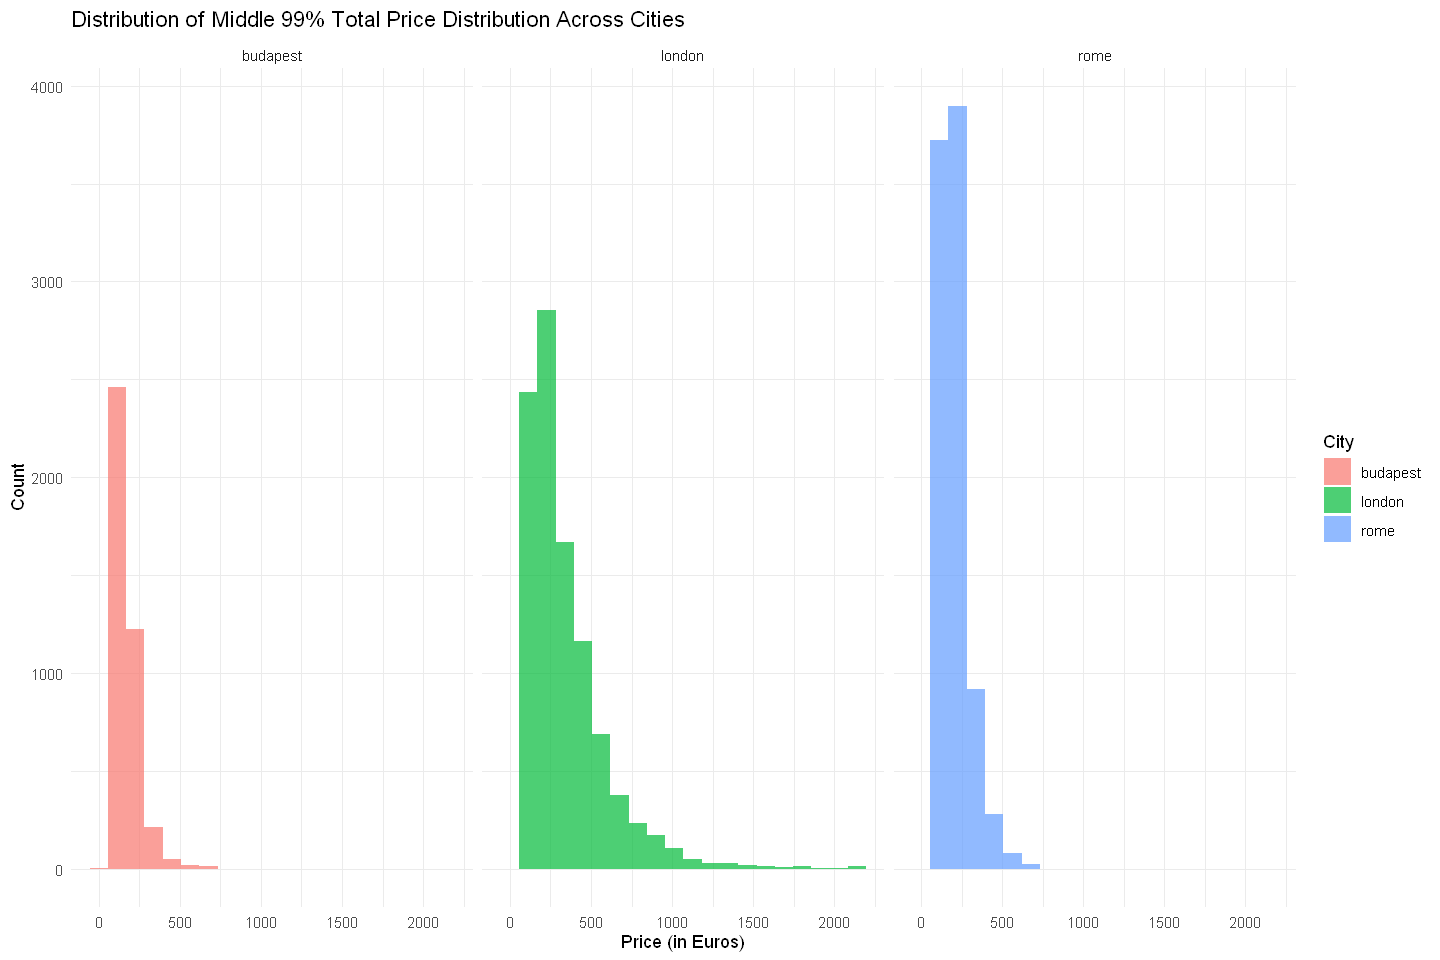

In [34]:
# We visualze the distribution of total price across cities
# focusing on the middle 99% of the price distribution to avoid extreme outliers skewing the results
price_99_distribution_mid <- airbnb_data|>
    group_by(city)|>
    filter(realSum > quantile(realSum, 0.005, na.rm = TRUE) & realSum < quantile(realSum, 0.995, na.rm = TRUE)) |>
    ungroup()|>
    ggplot(aes(x = realSum, fill = city)) +
    geom_histogram(bins = 20, alpha = 0.7) +
    facet_wrap(~ city, ncol = 3) +
    labs(title = "Distribution of Middle 99% Total Price Distribution Across Cities", x = "Price (in Euros)", y = "Count", fill = "City") +
    theme_minimal()

price_99_distribution_mid

To better investigate the relationships of all other numeric explanatory variables with the total price of listings, I create a scatter plot matrix to visualize the relationships between the numerical variables..

Warning message:
"Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(varaibles)

  # Now:
  data %>% select(all_of(varaibles))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>."
`geom_smooth()` using formula = 'y ~ x'


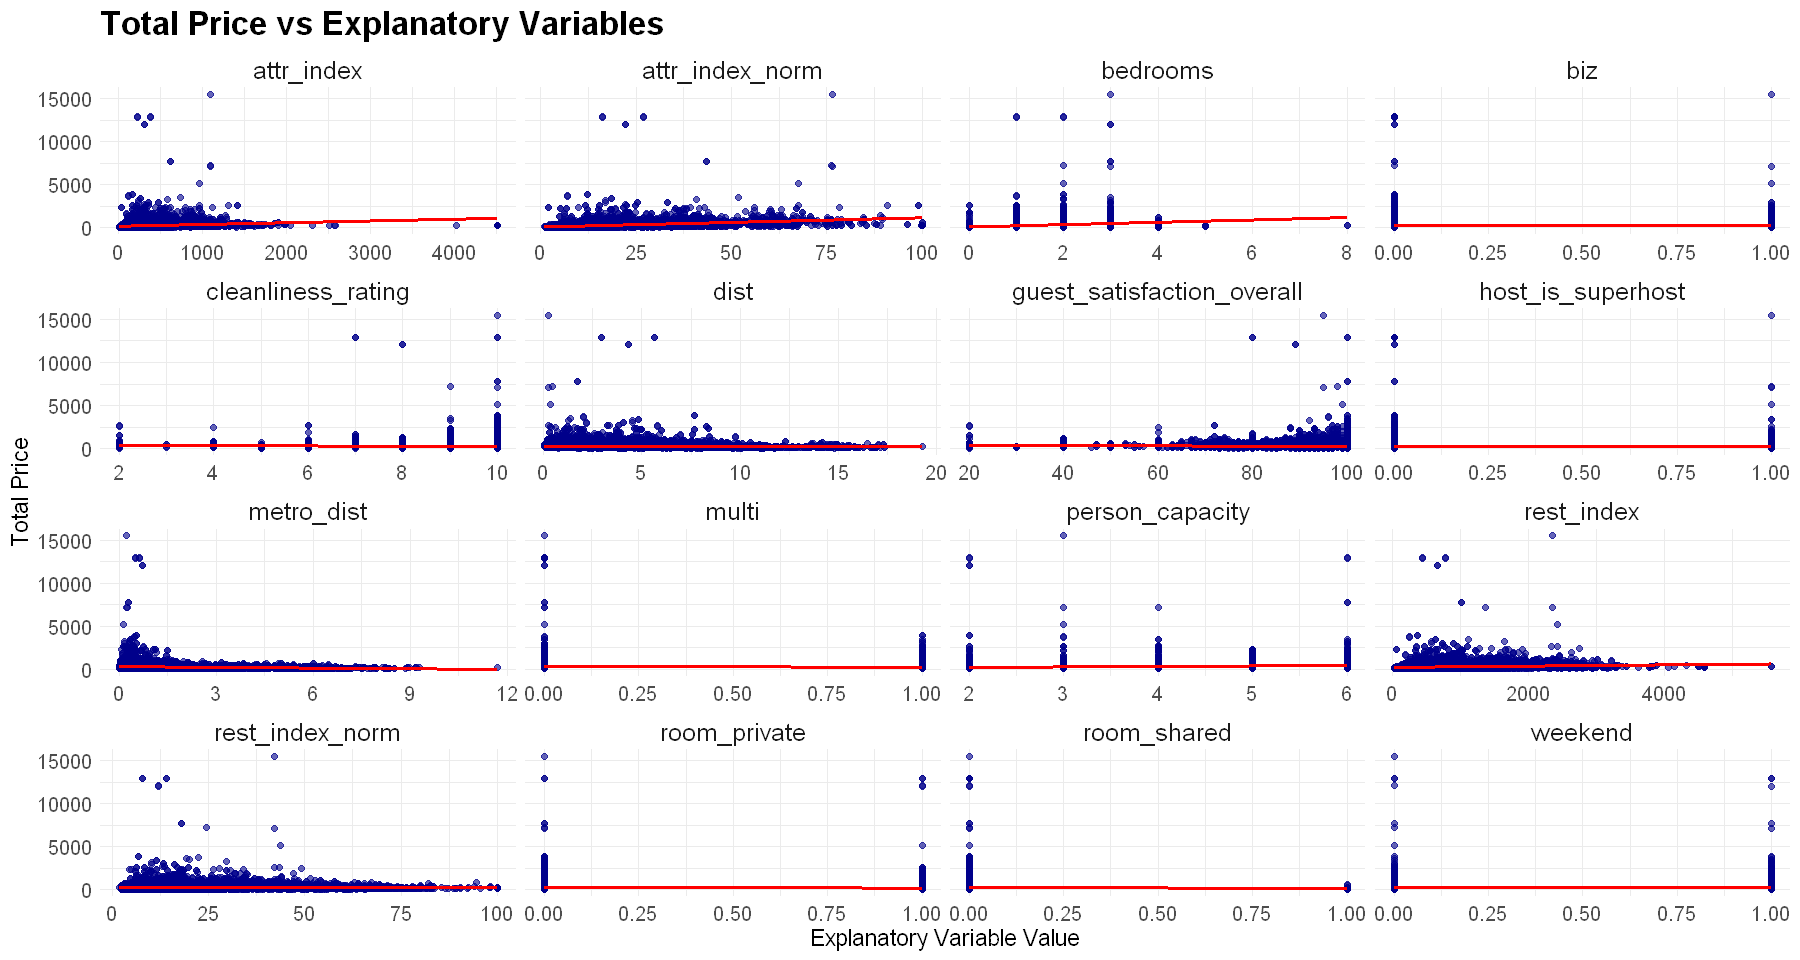

In [35]:
options(repr.plot.width = 15, repr.plot.height = 8)
# Define the variable list for scatter plots of explanatory variables against the total price
varaibles <- colnames(airbnb_data)[!colnames(airbnb_data) %in% c("realSum", "lat", "lng", "city", "room_type")]

# Convert the data to long format for scatter plots
long_data <-  airbnb_data|>
  pivot_longer(cols = varaibles,
               names_to = "variables",
               values_to = "value")

# Create scatter plots for each explanatory variable against the total price
variables_scatter <- ggplot(long_data , aes(x = value, y = realSum)) +
  geom_point(color = "darkblue", alpha = 0.6) +
  facet_wrap(~ variables, scales = "free_x") + 
  labs(title = "Total Price vs Explanatory Variables",
       x = "Explanatory Variable Value",
       y = "Total Price") +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  theme_minimal() +
  theme(plot.title = element_text(size = 20, face = "bold"),
        strip.text = element_text(size = 15),  
        axis.title = element_text(size = 14),
        axis.text = element_text(size = 12))

variables_scatter

I noticed that with the large variation in the total price of listings, the OLS estimation is significantly afffected by the outliers. Therefore, I will transform the `realSum` variable to a log scale to reduce the impact of outliers and better visualize the relationships between the variables, also for better explanation of the results in the subsequent analyses.

`geom_smooth()` using formula = 'y ~ x'


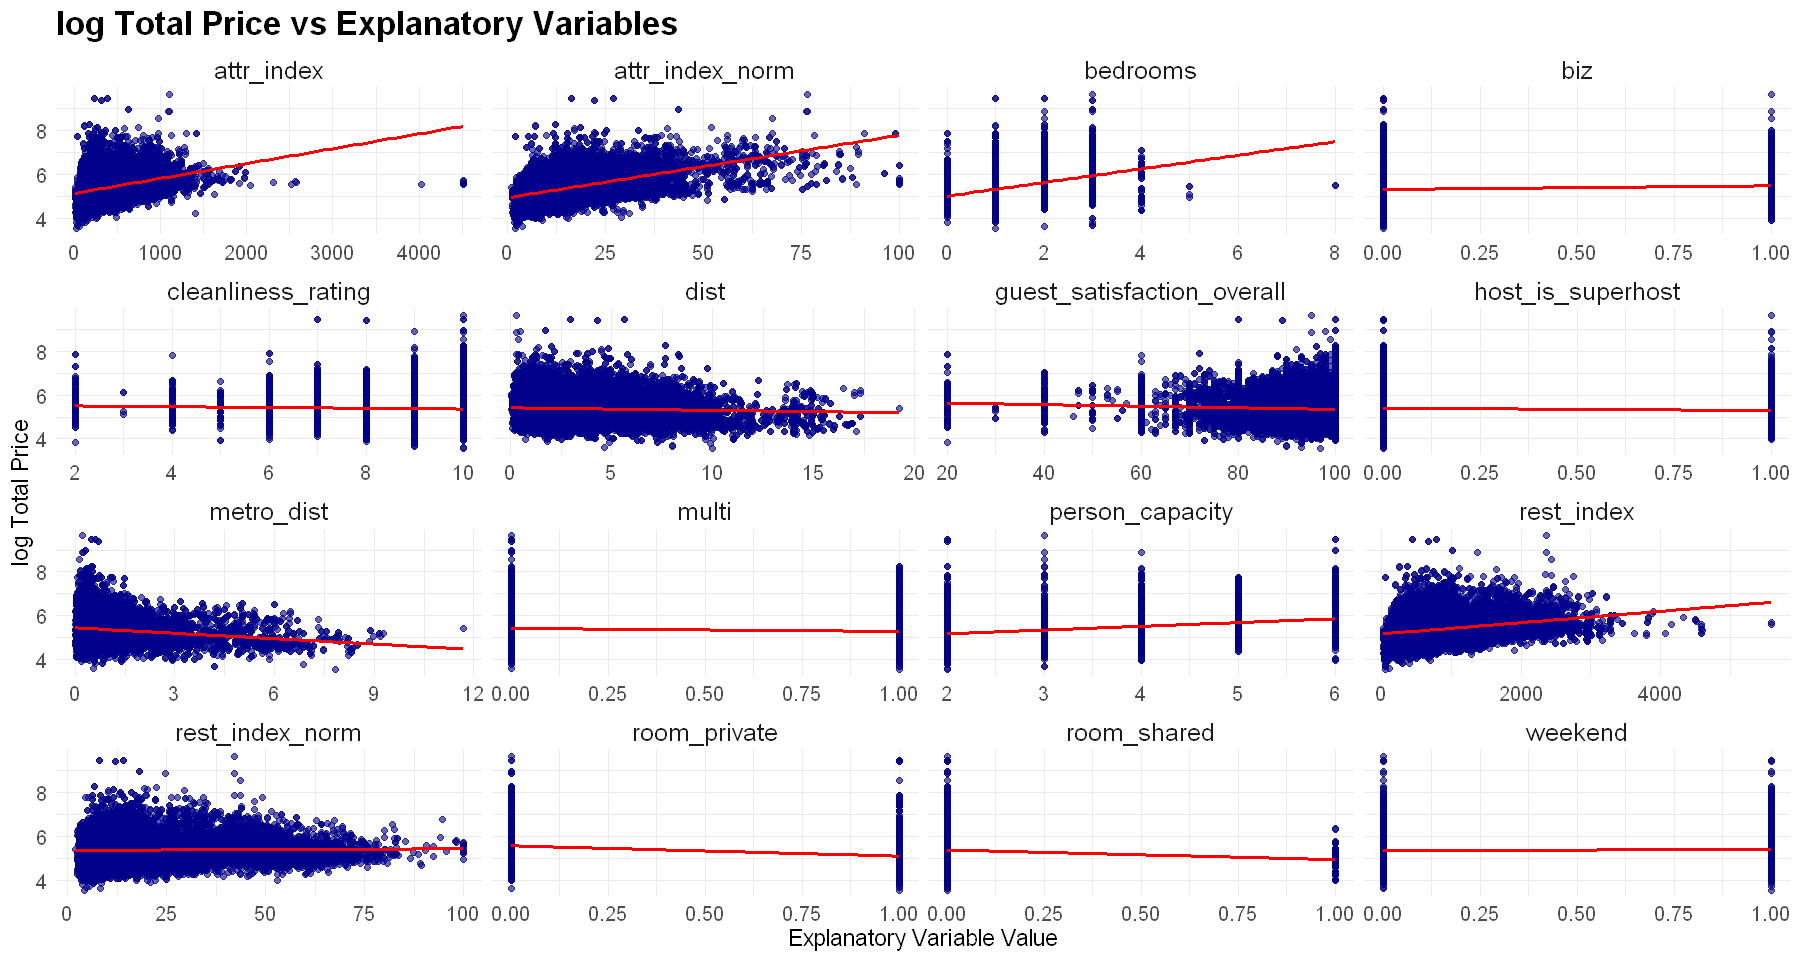

In [36]:
options(repr.plot.width = 15, repr.plot.height = 8)

# Define the variable list for scatter plots of explanatory variables against the log(total price)
varaibles <- colnames(airbnb_data)[!colnames(airbnb_data) %in% c("realSum", "lat", "lng", "city", "room_type")]

# Convert the data to long format for scatter plots
long_data <-  airbnb_data|>
  mutate(realSum = log(realSum)) |>
  pivot_longer(cols = varaibles,
               names_to = "variables",
               values_to = "value")

# Create scatter plots for each explanatory variable against the total price
variables_scatter <- ggplot(long_data , aes(x = value, y = realSum)) +
  geom_point(color = "darkblue", alpha = 0.6) +
  facet_wrap(~ variables, scales = "free_x") + 
  labs(title = "log Total Price vs Explanatory Variables",
       x = "Explanatory Variable Value",
       y = "log Total Price") +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  theme_minimal() +
  theme(plot.title = element_text(size = 20, face = "bold"),
        strip.text = element_text(size = 15),  
        axis.title = element_text(size = 14),
        axis.text = element_text(size = 12))

variables_scatter

It is clear that by transforming the `realSum` variable to a log scale, the linear models better capture the relationships between the response and predictors, and we can interpret the coefficients of the linear models in terms of percentage change in the total price of listings for a one unit change in the predictor variables. This is also the response variable used in Gyódi &  Nawaro (2020) study, which is the original source of the dataset.

#### Testing Response Candidate: `Overall Satisfaction`

In addition to the total price of listings, I will also focus on the overall satisfaction score of listings (`guest_satisfaction_overall`) as the response variable. I will begin exploring by plotting the histograms of the overall satisfaction scores to understand its distribution.

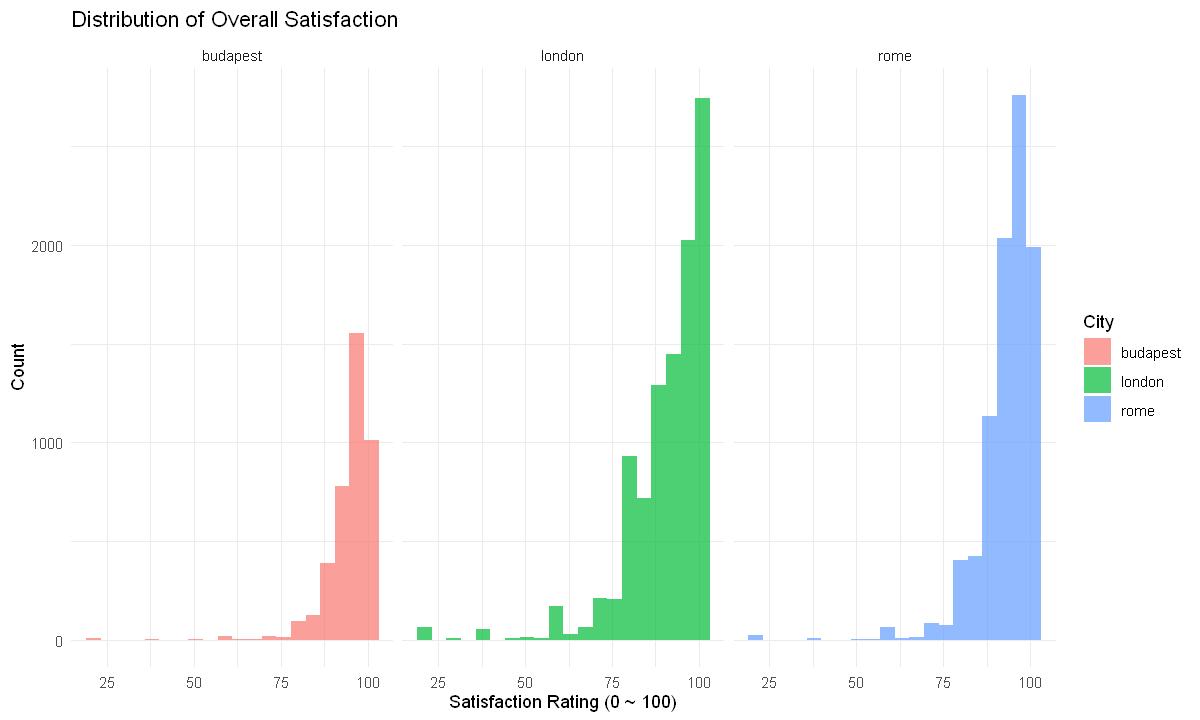

In [37]:
options(repr.plot.width = 10, repr.plot.height = 6)
# Visualize the distribution of satisfaction across cities with separate plots
city_satisfaction_distribution <- ggplot(airbnb_data, aes(x = guest_satisfaction_overall, fill = city)) +
    geom_histogram(bins = 20, alpha = 0.7) +
    facet_wrap(~ city, ncol = 3) +
    labs(title = "Distribution of Overall Satisfaction", x = "Satisfaction Rating (0 ~ 100)", y = "Count", fill = "City") +
    theme_minimal()

city_satisfaction_distribution

As we can see above, the overall satisfaction scores are generally high, with most listings receiving scores above 80. However, there are also some listings with very low scores, indicating that there may be some outliers or poorly rated listings in the dataset.

I will also visualize using a boxplot to better understand the distribution of overall satisfaction scores across different cities, weekend and room types.

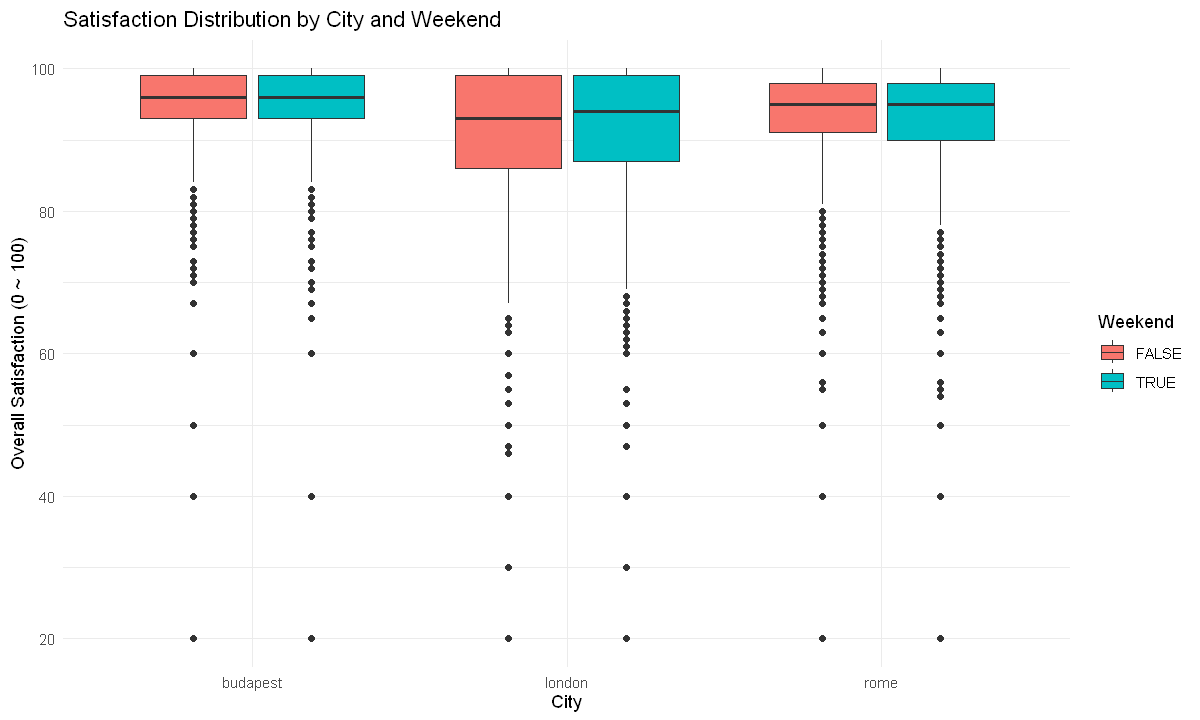

In [38]:
options(repr.plot.width = 10, repr.plot.height = 6)
# Create box plots for satisfaction distribution by city and weekend
satisfaction_boxplot <- ggplot(airbnb_data, aes(x = city, y = guest_satisfaction_overall, fill = weekend)) +
    geom_boxplot() +
    labs(title = "Satisfaction Distribution by City and Weekend", x = "City", y = "Overall Satisfaction (0 ~ 100)", fill = "Weekend") +
    theme_minimal()

satisfaction_boxplot

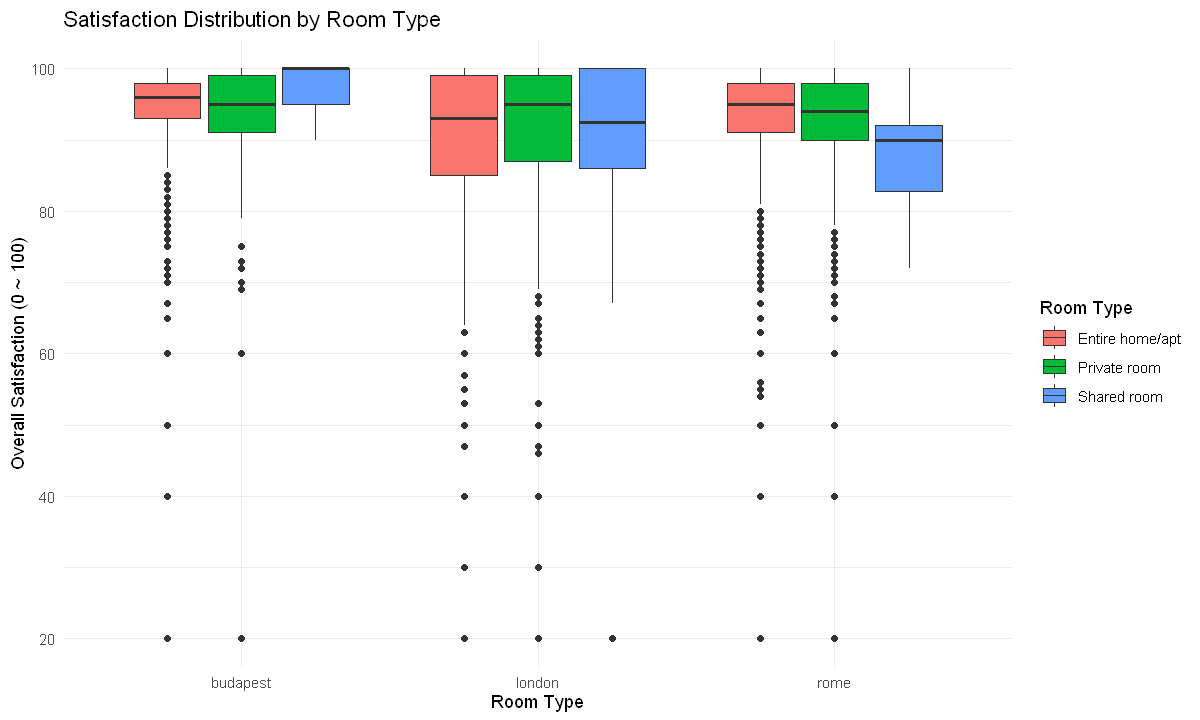

In [39]:
# Visualize the satisfactory against room type to see if there is a relationship
satisfaction_room_type_plot <- ggplot(airbnb_data, aes(x = city, y = guest_satisfaction_overall, fill = room_type)) +
    geom_boxplot() +
    labs(title = "Satisfaction Distribution by Room Type", x = "Room Type", y = "Overall Satisfaction (0 ~ 100)", fill = "Room Type") +
    theme_minimal()

satisfaction_room_type_plot

It can be seen from above boxplots that the overall satisfaction scores are heterogeneous across different cities, with Budapest having the highest overall satisfaction scores, followed by London and Rome, and the overall satisfaction scores differ by room types. However, across weekday and weekend listings, the overall satisfaction scores are relatively similar, with no significant difference between the two groups visually.

I carry out ANOVA and t-tests to confirm the differences in overall satisfaction scores across different cities, weekend and room types.

In [40]:
# anova for satisfaction differences between cities
anova_satisfaction_city <- aov(guest_satisfaction_overall ~ city, data = airbnb_data)

summary(anova_satisfaction_city)

               Df  Sum Sq Mean Sq F value Pr(>F)    
city            2   54458   27229   306.6 <2e-16 ***
Residuals   23039 2046387      89                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [41]:
# t-test for satisfaction differences between weekends and weekdays
t_test_satisfaction_weekend <- t.test(guest_satisfaction_overall ~ weekend, data = airbnb_data)

t_test_satisfaction_weekend


	Welch Two Sample t-test

data:  guest_satisfaction_overall by weekend
t = -0.68036, df = 22936, p-value = 0.4963
alternative hypothesis: true difference in means between group FALSE and group TRUE is not equal to 0
95 percent confidence interval:
 -0.3324204  0.1611114
sample estimates:
mean in group FALSE  mean in group TRUE 
           92.25948            92.34514 


In [42]:
# anova for satisfaction differences between room types
anova_satisfaction_room_type <- aov(guest_satisfaction_overall ~ room_type, data = airbnb_data)
summary(anova_satisfaction_room_type)

               Df  Sum Sq Mean Sq F value   Pr(>F)    
room_type       2    1507   753.4   8.269 0.000257 ***
Residuals   23039 2099339    91.1                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

The results are indeed as what we hypothesized, with significant differences in overall satisfaction scores across different cities and room types, with p-values less than 0.05, but no significant difference between weekday and weekend listings, with a p-value greater than 0.05.

We then proceed to visualize the relationships between the overall satisfaction scores and the numerical variables in the dataset. I create a scatter plot matrix to visualize the relationships between the numerical variables, with the overall satisfaction scores `guest_satisfaction_overall` as the response variable.

`geom_smooth()` using formula = 'y ~ x'


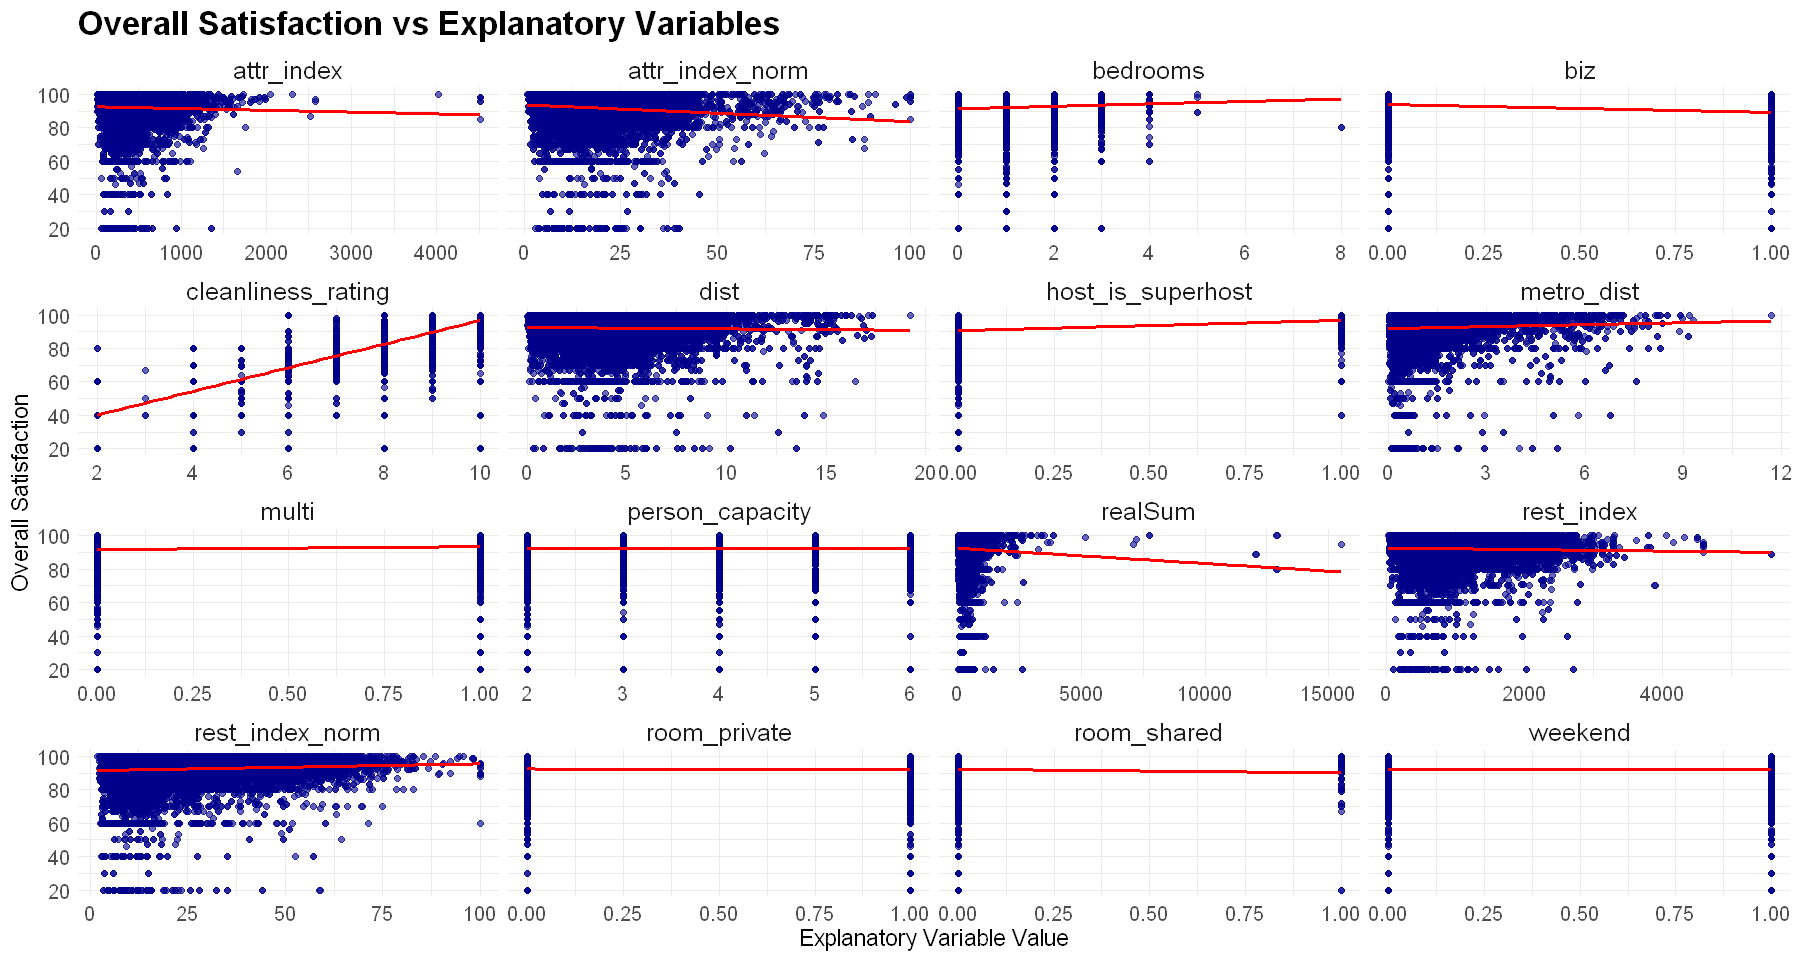

In [43]:
options(repr.plot.width = 15, repr.plot.height = 8)

# Define the variable list for scatter plots of explanatory variables against the overall satisfaction
varaibles <- colnames(airbnb_data)[!colnames(airbnb_data) %in% c("guest_satisfaction_overall", "lat", "lng", "city", "room_type")]

# Convert the data to long format for scatter plots
long_data <-  airbnb_data|>
  pivot_longer(cols = varaibles,
               names_to = "variables",
               values_to = "value")

# Create scatter plots for each explanatory variable against the satisfaction
variables_scatter <- ggplot(long_data , aes(x = value, y = guest_satisfaction_overall)) +
  geom_point(color = "darkblue", alpha = 0.6) +
  facet_wrap(~ variables, scales = "free_x") + 
  labs(title = "Overall Satisfaction vs Explanatory Variables",
       x = "Explanatory Variable Value",
       y = "Overall Satisfaction") +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  theme_minimal() +
  theme(plot.title = element_text(size = 20, face = "bold"),
        strip.text = element_text(size = 15),  
        axis.title = element_text(size = 14),
        axis.text = element_text(size = 12))

variables_scatter

Since the overall satisfaction scores are non-negative integers between 0 and 100, I also try to visualize with Poisson regression models to see if the relationships between the overall satisfaction scores and the numerical variables are better captured by a Poisson distribution. However, given the data is left-skewed, the Poisson regression models do not fit the data well, and the OLS models are still the best choice for modeling the relationships between the overall satisfaction scores and the numerical variables.

`geom_smooth()` using formula = 'y ~ x'


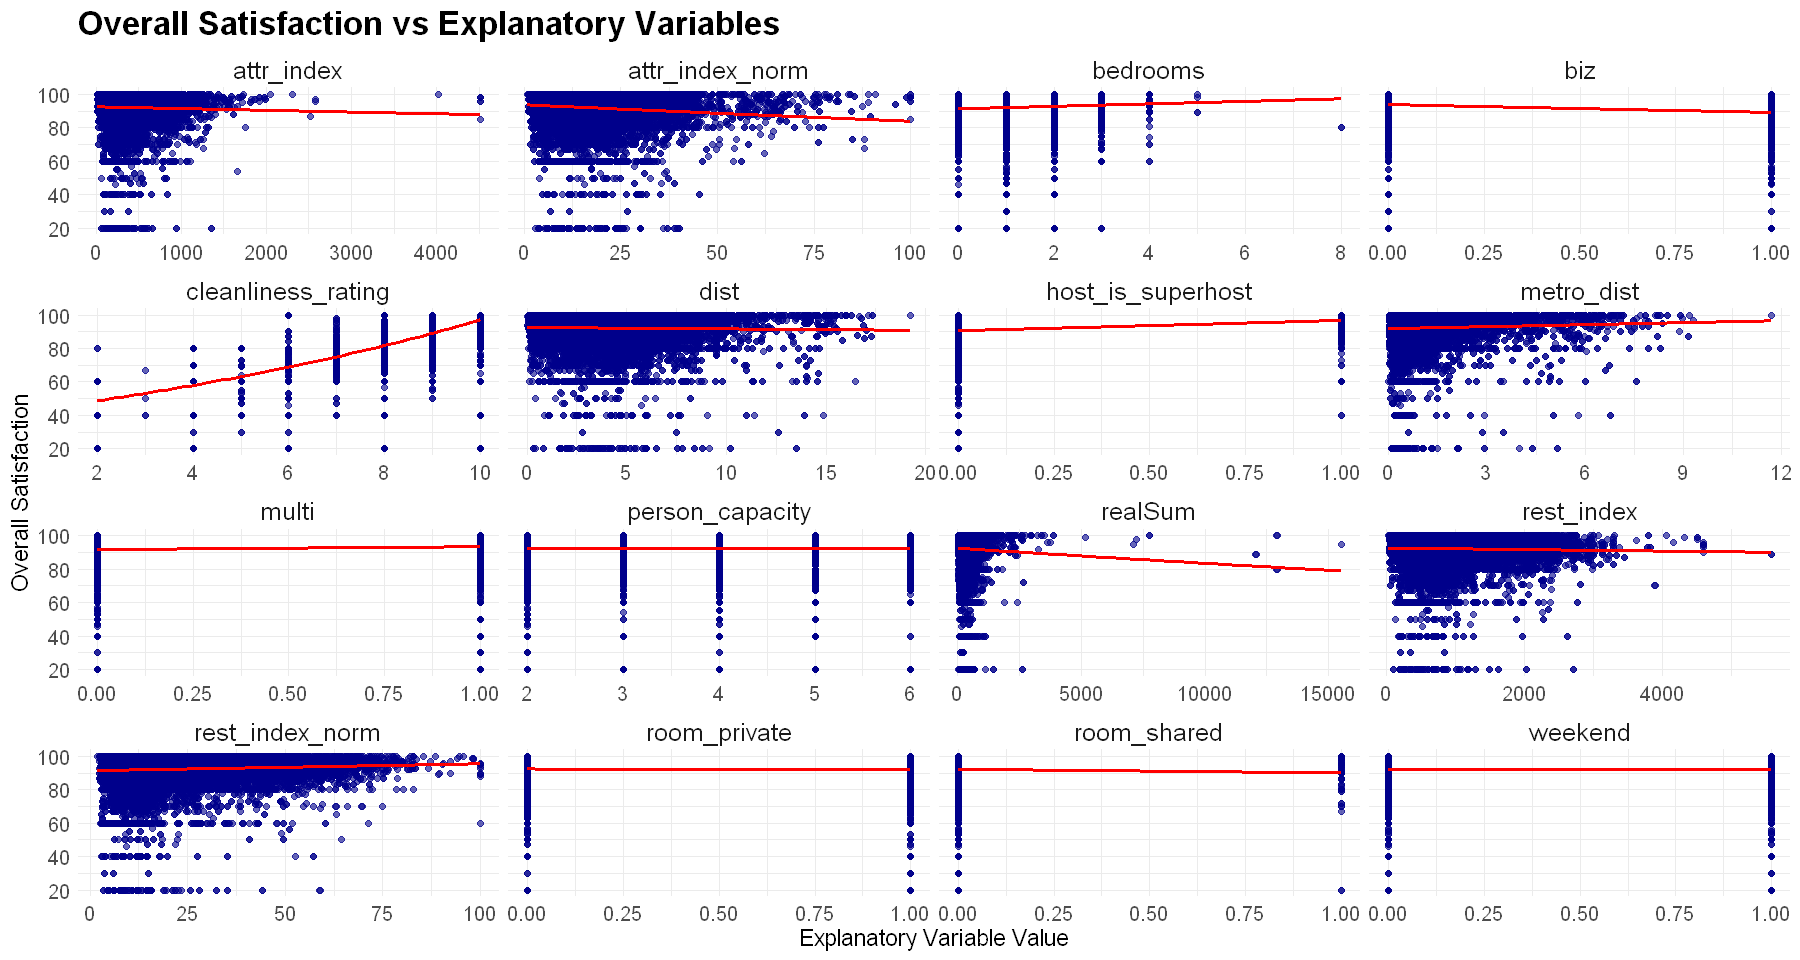

In [44]:
options(repr.plot.width = 15, repr.plot.height = 8)

# We plot the distribution of overall satisfaction against other variables with poisson distribution to see if there are relationships
varaibles <- colnames(airbnb_data)[!colnames(airbnb_data) %in% c("guest_satisfaction_overall", "lat", "lng", "city", "room_type")]

# Convert the data to long format for scatter plots
long_data <-  airbnb_data|>
  pivot_longer(cols = varaibles,
               names_to = "variables",
               values_to = "value")

# Create scatter plots for each explanatory variable against the satisfaction
variables_scatter <- ggplot(long_data , aes(x = value, y = guest_satisfaction_overall)) +
  geom_point(color = "darkblue", alpha = 0.6) +
  facet_wrap(~ variables, scales = "free_x") + 
  labs(title = "Overall Satisfaction vs Explanatory Variables",
       x = "Explanatory Variable Value",
       y = "Overall Satisfaction") +
  geom_smooth(method = "glm", se = FALSE, color = "red", method.args = list(family = poisson)) +
  theme_minimal() +
  theme(plot.title = element_text(size = 20, face = "bold"),
        strip.text = element_text(size = 15),  
        axis.title = element_text(size = 14),
        axis.text = element_text(size = 12))

variables_scatter

As we can see, the Poisson regression dits are generally not too different from the OLS regression fits, but the OLS regression fits are more consistent with the data in terms of the assumptions required. 

### Task (4) Methods and Plan

Based on the exploratory data analysis and visualizations, I will proceed with the following methods to answer the candidate questions:

For the total price of listings in Euro `realSum`, I will transform the it into a natural logarithm scale and use the log `realSum` as the response variable in the linear regression models. I will use the `lm()` function to fit the linear regression models. The full model will be of the form:
$$
\log(\text{Total Price}_i) = \beta_0 + \gamma D_i + \sum_{j=1}^k \beta_j X_{j,i} + \sum_{t=1}^p \theta_t (D_i \times X_{j,i}) + \epsilon_i
$$

In which $D_i$ is the treatment variable if there is indeed a causal relationship between the response and the treatment variable, and $X_{j, i}$ are the other explanatory variables in the model. I also include interaction terms to capture the potential heterogeneity in the treatment effects across different levels of the explanatory variables. I assume the error term $\epsilon_i$ is assumed to be normally distributed with mean 0 and constant variance.

After fitting the full model, I will use backward elimination to remove the least significant variables iteratively until I reach a final model that includes only the most significant predictors. I will also check the assumptions of the linear regression models, including linearity, independence, homoscedasticity, and normality of residuals.

For the overall satisfaction score of listings `guest_satisfaction_overall`, I will use the OLS regression models with the `lm()` function to fit the linear regression models. The full model will be of the form:

$$
\text{Overall Satisfaction}_i = \beta_0 + \gamma D_i + \sum_{j=1}^k \beta_j X_{j,i} + \sum_{t=1}^p \theta_t (D_i \times X_{j,i}) + \epsilon_i
$$

In which $D_i$ is the treatment variable if there is indeed a causal relationship between the response and the treatment variable, and $X_{j, i}$ are the other explanatory variables in the model. I also include interaction terms to capture the potential heterogeneity in the treatment effects across different levels of the explanatory variables. I assume the error term $\epsilon_i$ is assumed to be normally distributed with mean 0 and constant variance.

Similar to the total price of listings, I will use backward elimination to remove the least significant variables iteratively until I reach a final model that includes only the most significant predictors. I will also check the assumptions of the linear regression models, including linearity, independence, homoscedasticity, and normality of residuals.

#### Model Proposal for Using log `realSum` as Response Variable

In this section, I will try to fit the linear regression models with the log `realSum` as the response variable. I will first fit the full additive model with all the variables in the dataset, and evaluate the model performance using `summary()`, `glance()` and `tidy()` functions.I will also check multicollinearity using the Variance Inflation Factor (VIF), implemented by `vif()`, to ensure that the model does not suffer from multicollinearity issues.

In [45]:
log_price_model <- lm(log(realSum) ~ city + weekend + room_type + host_is_superhost + multi + biz + bedrooms + dist + metro_dist + attr_index_norm + rest_index_norm, data = airbnb_data)

summary(log_price_model)


Call:
lm(formula = log(realSum) ~ city + weekend + room_type + host_is_superhost + 
    multi + biz + bedrooms + dist + metro_dist + attr_index_norm + 
    rest_index_norm, data = airbnb_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.4470 -0.2356 -0.0333  0.1903  4.2134 

Coefficients:
                        Estimate Std. Error  t value Pr(>|t|)    
(Intercept)            4.5989665  0.0132122  348.084  < 2e-16 ***
citylondon             0.8492089  0.0127248   66.737  < 2e-16 ***
cityrome               0.3561789  0.0073980   48.145  < 2e-16 ***
weekendTRUE            0.0336784  0.0048040    7.011 2.44e-12 ***
room_typePrivate room -0.5673004  0.0054516 -104.062  < 2e-16 ***
room_typeShared room  -0.6717330  0.0419181  -16.025  < 2e-16 ***
host_is_superhostTRUE  0.0127498  0.0056415    2.260   0.0238 *  
multi                  0.0483569  0.0061120    7.912 2.65e-15 ***
biz                    0.0675595  0.0061323   11.017  < 2e-16 ***
bedrooms               0.2374333  0.0

In [46]:
tidy(log_price_model, exponentiate = TRUE, conf.int = TRUE)

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),99.3815478,0.0132122262,348.084146,0.000000e+00,96.8409180,101.9888312
citylondon,2.3377967,0.0127247548,66.736761,0.000000e+00,2.2802100,2.3968378
cityrome,1.4278629,0.0073979946,48.145327,0.000000e+00,1.4073075,1.4487186
weekendTRUE,1.0342519,0.0048039639,7.010541,2.439553e-12,1.0245590,1.0440365
room_typePrivate room,0.5670542,0.0054515716,-104.061809,0.000000e+00,0.5610272,0.5731459
room_typeShared room,0.5108226,0.0419180529,-16.024909,1.752209e-57,0.4705302,0.5545653
host_is_superhostTRUE,1.0128314,0.0056414518,2.260023,2.382910e-02,1.0016936,1.0240931
multi,1.0495452,0.0061120196,7.911777,2.651029e-15,1.0370467,1.0621943
biz,1.0698939,0.0061323048,11.016983,3.721419e-28,1.0571111,1.0828313


In [47]:
vif(log_price_model)

,GVIF,Df,GVIF^(1/(2*Df))
city,5.169292,2,1.507849
weekend,1.005638,1,1.002815
room_type,1.254799,2,1.058385
host_is_superhost,1.074581,1,1.036620
multi,1.426038,1,1.194168
biz,1.511507,1,1.229434
bedrooms,1.063840,1,1.031426
dist,4.487651,1,2.118408
metro_dist,1.881565,1,1.371701
attr_index_norm,3.297486,1,1.815898


In [48]:
glance(log_price_model)

r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.6147075,0.61449,0.3634282,2826.122,0,13,-9365.675,18761.35,18882.03,3041.539,23028,23042


`geom_smooth()` using formula = 'y ~ x'


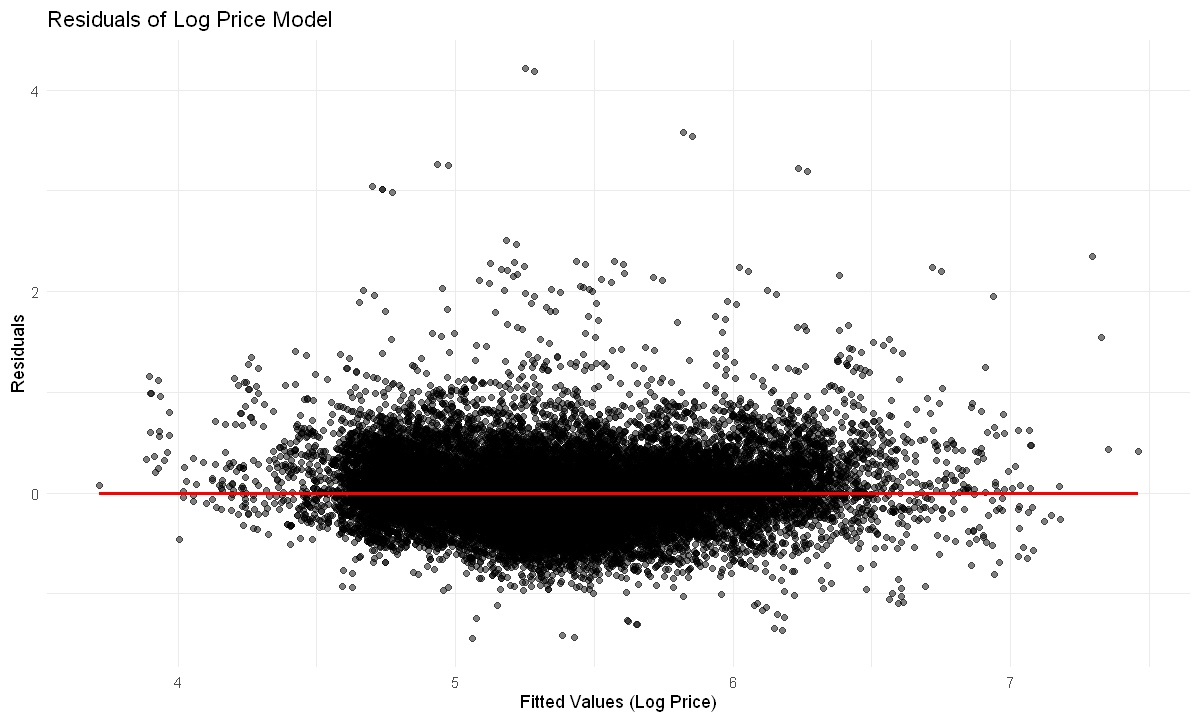

In [49]:
# Visualize the residuals of the log price model
options(repr.plot.width = 10, repr.plot.height = 6)

residuals_plot <- ggplot(log_price_model, aes(x = .fitted, y = .resid)) +
    geom_point(alpha = 0.5) +
    geom_smooth(method = "lm", color = "red", se = FALSE) +
    labs(title = "Residuals of Log Price Model",
         x = "Fitted Values (Log Price)",
         y = "Residuals") +
    theme_minimal()

residuals_plot

By this eyeball test, I see we are probably suffering from heteroskedasticity, as the residuals are not evenly distributed around zero. 

#### Model Proposal for Using `guest_satisfaction_overall` as Response Variable

Similarly, I will fit the linear regression models with the `guest_satisfaction_overall` as the response variable, and examine the model performance using `summary()`, `glance()` and `tidy()` functions. I will also check multicollinearity using the Variance Inflation Factor (VIF), implemented by `vif()`, to ensure that the model does not suffer from multicollinearity issues, and check the assumptions of the linear regression models, including linearity, independence, homoscedasticity by plotting the residuals against the fitted values.

In [50]:
satisfaction_model <- lm(guest_satisfaction_overall ~ city + weekend + room_type + host_is_superhost + multi + biz + bedrooms + dist + metro_dist + attr_index_norm + rest_index_norm, data = airbnb_data)

summary(satisfaction_model)


Call:
lm(formula = guest_satisfaction_overall ~ city + weekend + room_type + 
    host_is_superhost + multi + biz + bedrooms + dist + metro_dist + 
    attr_index_norm + rest_index_norm, data = airbnb_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-75.494  -2.472   1.048   5.109  13.904 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)           92.861183   0.322689 287.773  < 2e-16 ***
citylondon            -3.257680   0.310783 -10.482  < 2e-16 ***
cityrome              -1.413300   0.180685  -7.822 5.43e-15 ***
weekendTRUE            0.082172   0.117330   0.700  0.48371    
room_typePrivate room  0.794852   0.133146   5.970 2.41e-09 ***
room_typeShared room  -0.554439   1.023785  -0.542  0.58813    
host_is_superhostTRUE  5.109544   0.137784  37.084  < 2e-16 ***
multi                 -1.511013   0.149277 -10.122  < 2e-16 ***
biz                   -4.579232   0.149772 -30.575  < 2e-16 ***
bedrooms               0.547868   0.102887 

In [51]:
tidy(satisfaction_model, conf.int = TRUE)

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),92.86118285,0.322688672,287.7732967,0.000000e+00,92.228691428,93.49367427
citylondon,-3.25767958,0.310782919,-10.4821706,1.191636e-25,-3.866834930,-2.64852424
cityrome,-1.41329954,0.180684845,-7.8219042,5.425569e-15,-1.767453947,-1.05914514
weekendTRUE,0.08217203,0.117329564,0.7003523,4.837144e-01,-0.147801772,0.31214584
room_typePrivate room,0.79485180,0.133146403,5.9697579,2.410855e-09,0.533875924,1.05582767
room_typeShared room,-0.55443851,1.023785139,-0.5415575,5.881286e-01,-2.561125983,1.45224897
host_is_superhostTRUE,5.10954351,0.137783942,37.0837373,1.996223e-292,4.839477747,5.37960926
multi,-1.51101289,0.149276850,-10.1222185,4.943992e-24,-1.803605522,-1.21842027
biz,-4.57923184,0.149772285,-30.5746277,2.790857e-201,-4.872795555,-4.28566813


In [52]:
vif(satisfaction_model)

,GVIF,Df,GVIF^(1/(2*Df))
city,5.169292,2,1.507849
weekend,1.005638,1,1.002815
room_type,1.254799,2,1.058385
host_is_superhost,1.074581,1,1.036620
multi,1.426038,1,1.194168
biz,1.511507,1,1.229434
bedrooms,1.063840,1,1.031426
dist,4.487651,1,2.118408
metro_dist,1.881565,1,1.371701
attr_index_norm,3.297486,1,1.815898


In [53]:
glance(satisfaction_model)

r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.1363959,0.1359084,8.876184,279.7689,0,13,-82997.43,166024.9,166145.5,1814299,23028,23042


`geom_smooth()` using formula = 'y ~ x'


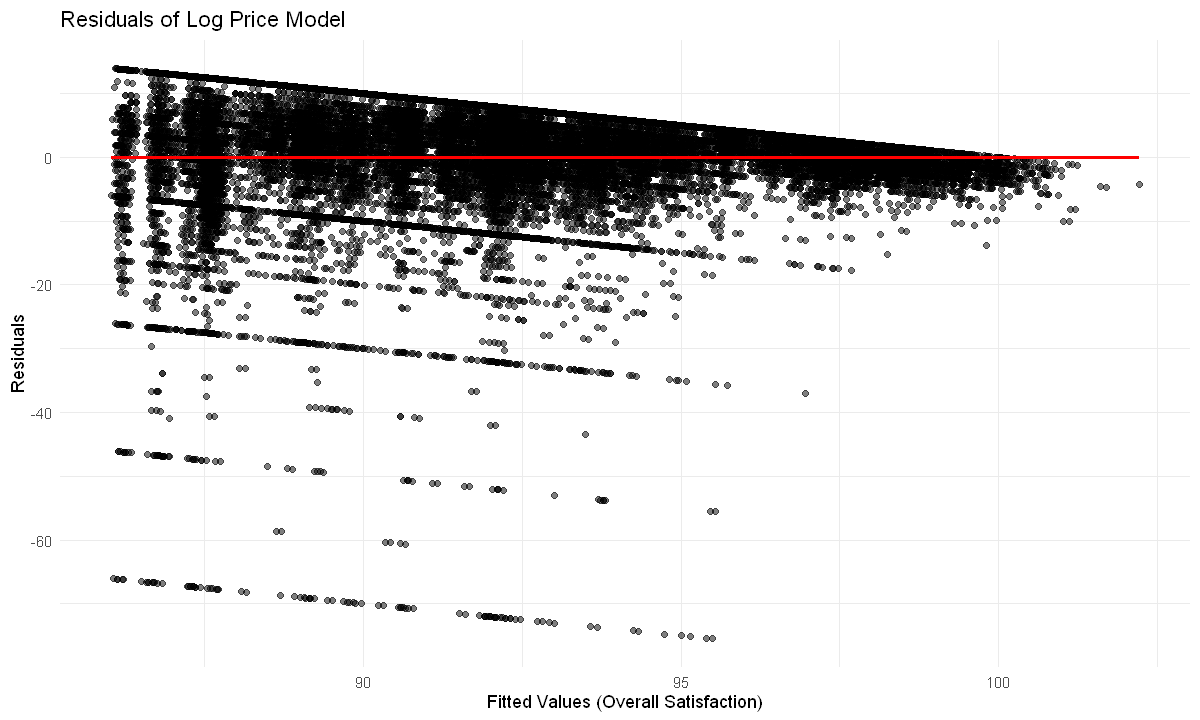

In [54]:
# Visualize the residuals of the log price model
options(repr.plot.width = 10, repr.plot.height = 6)

residuals_plot <- ggplot(satisfaction_model, aes(x = .fitted, y = .resid)) +
    geom_point(alpha = 0.5) +
    geom_smooth(method = "lm", color = "red", se = FALSE) +
    labs(title = "Residuals of Log Price Model",
         x = "Fitted Values (Overall Satisfaction)",
         y = "Residuals") +
    theme_minimal()

residuals_plot

Based on this visualization, this model is having a very strong non-linearity and heteroskedasticity issue, as the residuals are not evenly distributed around zero. 

### References

- Devastator. (n.d.). *Airbnb Prices in European Cities*. Kaggle. Retrieved from https://www.kaggle.com/datasets/thedevastator/airbnb-prices-in-european-cities/data
- Gyódi &  Nawaro. (2021). *Determinants of Airbnb prices in European cities: A spatial econometrics approach (Supplementary Material)*. Retrieved from https://zenodo.org/records/4446043#.Y9Y9ENJBwUE